In [1]:
#technical the per class knn is set to 1 neighbor which is not the deault. Mention this in thesis even though results might be slighlty differetnt should not be a big difference.

In [2]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "tu_berlin"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",

}



architecture = default_architecutre_mapping[dataset]
budget = None

In [3]:
from utils.transforms.apply import grid_resample_border,grid_resample_reflection

In [4]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

Loaded cached TU-Berlin dataset (max_len=200, interpolation_points=2)


In [5]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [6]:
x=next(iter(test_loader_transformed))[0]

In [7]:
batch_size = next(iter(train_loader))[0].shape[0]


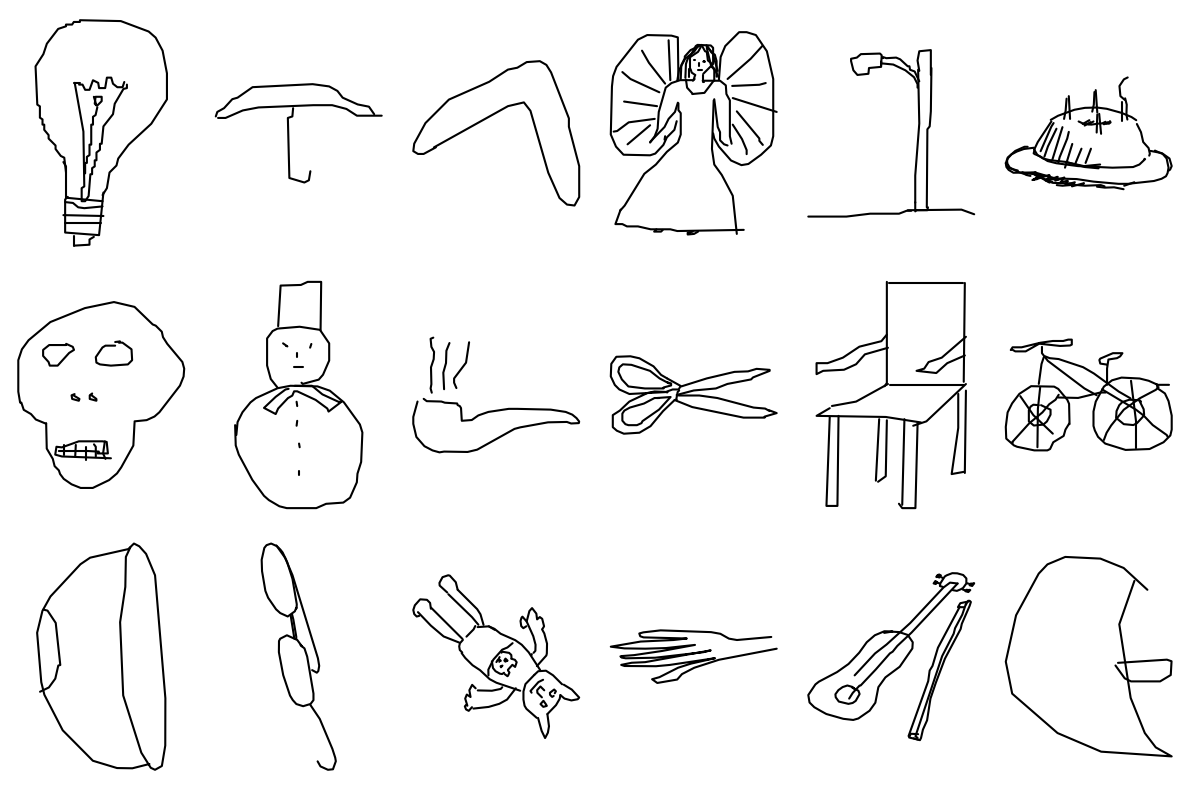

In [8]:
from utils.eval.vis import vis_dataset

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [9]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network, StrokeAugment
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparision_over_budget")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [10]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm.safetensors


(BILSTMSKETCHClassifier(
   (preprocess): NormalizeToRangeBatched()
   (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
   (attention): Linear(in_features=512, out_features=1, bias=False)
   (attn_dropout): Dropout(p=0.2, inplace=False)
   (augmentation): StrokeAugment()
   (classifier): Sequential(
     (0): Linear(in_features=512, out_features=512, bias=True)
     (1): GELU(approximate='none')
     (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
     (3): Dropout(p=0.5, inplace=False)
     (4): Linear(in_features=512, out_features=250, bias=True)
   )
 ),
 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\tu_berlin_bi_lstm.safetensors')

In [11]:
model.eval().to(device)

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [12]:
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)

{'accuracy': 0.0820000022649765, 'f2_macro': 0.07489944994449615, 'f2_micro': 0.0820000022649765, 'f2_weighted': 0.07477008551359177}


In [13]:
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.515500009059906, 'f2_macro': 0.4997326731681824, 'f2_micro': 0.515500009059906, 'f2_weighted': 0.509273111820221}


In [14]:
res = evaluate_base_model(model, val_loader, device)
print(res)

{'accuracy': 0.5090000033378601, 'f2_macro': 0.5022533535957336, 'f2_micro': 0.5090000033378601, 'f2_weighted': 0.5015836954116821}


In [15]:
class TensorGeometricModelUnwrapper(torch.nn.Module):
    """
    Wrapper for a torch_geometric model that receives a tuple of (pos, y) as input and creates
    a Data object from it that is passed to the model.
    """
    def __init__(self):
        super(TensorGeometricModelUnwrapper, self).__init__()

    def forward(self, data):
        # pos and y are batched tensors from a DataLoader
        # need to reconstruct the original Data objects for torch_geometric models

        pos = data.pos
        batch = data.batch
        #split pos into individual tensors based on batch
        pos_list = torch.split(pos, torch.bincount(batch).tolist())
        return torch.stack(pos_list)

In [16]:
#chek if data is iamge data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [17]:
from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).to(device)

In [18]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0, num_classes=None, num_rotations=8)

In [19]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
random_search = SHGO(initial_samples=120, local_max_steps=0)

from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search, evaluate_confidence_and_search, \
    ITSWRAPPER


In [20]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.22050000727176666,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.22043593227863312,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.22050000727176666,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.21837306022644043,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.22050000727176666,
   'f2_macro': 0.22043593227863312,
   'f2_micro': 0.22050000727176666,
   'f2_weighted': 0.21837306022644043,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None}]}

In [21]:
model.to(device).eval()

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [22]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [23]:
if "modelnet10" in dataset:
    for init_method in ["individual","sobol"]:
        print(f"Testing init method: {init_method}")
        import torch
        import kornia
        import matplotlib.pyplot as plt
        import numpy as np
        from mpl_toolkits.mplot3d import Axes3D
        from utils.affine_transforms import AffineTransformations3D
        from utils.transform_sequence import TransformSequence
        from scipy import stats

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


        # Save original init method and temporarily switch to "individual"
        original_init = transform_seq.init_method
        transform_seq.init_method = init_method

        # --- 1. Generate your matrices ---
        zw = transform_seq.initial_param(1280)
        transform_seq.init_method = original_init
        matrix = transform_seq(zw)

        # --- 2. Extract rotation submatrices ---
        R = matrix[:, :3, :3]  # [N, 3, 3]

        # --- 3. Convert to axis–angle representation ---
        rotvec = kornia.geometry.conversions.rotation_matrix_to_axis_angle(R)  # [N, 3]
        theta = torch.linalg.norm(rotvec, dim=1)
        axis = torch.nn.functional.normalize(rotvec, dim=1)

        axis_np = axis.cpu().numpy()
        theta_np = theta.cpu().numpy()

        # --- 4. Quantitative checks ---

        # (a) Axis uniformity
        mean_axis = axis_np.mean(axis=0)
        spherical_var = 1 - np.linalg.norm(mean_axis)
        print("Axis mean vector:", mean_axis)
        print("Spherical variance (1 - |mean|):", spherical_var)

        # (b) Rotation angle
        sample_mean = np.mean(theta_np)
        theory_mean = np.pi/2 + 2/np.pi  # Correct expected mean for uniform SO(3)
        print(f"Sample mean rotation angle (rad): {sample_mean:.4f}")
        print(f"Theoretical mean rotation angle (rad): {theory_mean:.4f}")

        # (c) Kolmogorov–Smirnov test against theoretical CDF
        def F_theta(t):
            # CDF for p(theta) ∝ sin²(theta/2)
            return (t - np.sin(t)) / np.pi

        ks_stat, pval = stats.kstest(theta_np, F_theta)
        print(f"KS statistic: {ks_stat:.4f}, p-value: {pval:.4f}")

        # --- 5. Visualization ---

        fig = plt.figure(figsize=(12, 5))

        # Angle histogram
        plt.subplot(1, 2, 1)
        plt.hist(theta_np, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
        t_grid = np.linspace(0, np.pi, 200)
        plt.plot(t_grid, (2/np.pi) * np.sin(t_grid/2)**2, 'r-', lw=2, label='theoretical pdf')
        plt.xlabel("Rotation angle (radians)")
        plt.ylabel("Density")
        plt.title("Rotation Angle Distribution")
        plt.legend()

        # 3D scatter of axes
        ax = fig.add_subplot(1, 2, 2, projection='3d')
        ax.scatter(axis_np[:, 0], axis_np[:, 1], axis_np[:, 2], s=8, alpha=0.7)
        # Draw reference sphere
        u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
        x = np.cos(u)*np.sin(v)
        y = np.sin(u)*np.sin(v)
        z = np.cos(v)
        ax.plot_wireframe(x, y, z, color='gray', alpha=0.2)
        ax.set_box_aspect([1,1,1])
        ax.set_title("Rotation Axes on Unit Sphere")

        plt.tight_layout()
        plt.show()


In [24]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    affine_augment = utils.augments.build_default_augmentations()
else:
    if dataset in ["tu_berlin"]:
        transform_true_function = None
        affine_augment = StrokeAugment()
    else:
        transform_true_function = None
        affine_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=dec_strat,
)

energy_conf2 = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm_energy2_energy_conf_best.safetensors
Model has non-negative constraint: False


In [25]:
model.to(device).eval()

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [26]:
from model.pointnet_plus import SAModule
def set_deterministic_fps(model, random_start=False):
    for module in model.modules():
        if isinstance(module, SAModule):
            module.random_start = random_start
            print(f"Set random_start={random_start} for {module.__class__.__name__}")

set_deterministic_fps(model)
set_deterministic_fps(energy_model2)

In [27]:
energy_conf2.to(device).eval()



problem_energy2 = TransformationProblem(energy_conf2, transform_seq,                                              consolidate_method="consolidate_simple")



In [28]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_energy2,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed"), show_progress=True,
    repeats=1)

{'repeats': 1,
 'accuracy_mean': 0.3174999952316284,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.313396155834198,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.3174999952316284,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.314267635345459,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.3174999952316284,
   'f2_macro': 0.313396155834198,
   'f2_micro': 0.3174999952316284,
   'f2_weighted': 0.314267635345459,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None}]}

In [29]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [30]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache



cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))

dual_output_model = cache_train.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True)
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=layer_io, flatten=True)




from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=None,computation_mode="masked",k=1)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.to(device)

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")
model.eval().to(device)

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [31]:
#benchmark model and dual output model

In [32]:
load_or_run_evaluate_confidence_and_search(
    model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("knn_per_class_confidence_transformed"), show_progress=True,
    repeats=1,overwrite=False)

{'repeats': 1,
 'accuracy_mean': 0.14300000667572021,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.14253607392311096,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.14300000667572021,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.14182114601135254,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.14300000667572021,
   'f2_macro': 0.14253607392311096,
   'f2_micro': 0.14300000667572021,
   'f2_weighted': 0.14182114601135254,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None}]}

In [33]:
gc.collect()
torch.cuda.empty_cache()

In [34]:
x = next(iter(train_loader_no_shuffle))

res1= dual_output_model(x[0].to(device))[0].cpu().detach().numpy()

res2 = embeddings_t[:x[0].shape[0]].cpu().detach().numpy()
if not np.allclose(res1, res2):
    pass
    #raise ValueError("Model is not deterministic!")
else:
    print("Model is deterministic.")

del res1
del res2
del x

Model is deterministic.


In [35]:
from utils.eval.ood_performance import ITSWRAPPER
import importlib
import its.search
importlib.reload(its.search)

its2 = ITSWRAPPER(its.search.InverseTransformationSearch(model,None,None,n_hypotheses=1,n_samples=10,extend=0,gaussian_filter_channel_wise=True))

In [36]:
from search.tree import CoordinateDescent
cd = CoordinateDescent()

In [37]:
gc.collect(

)
torch.cuda.empty_cache()

In [38]:
gc.collect()
torch.cuda.empty_cache()

In [39]:
x = next(iter(test_loader_transformed))[0].to(device)

In [40]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [41]:
from utils.replacer import replace_rotation_transforms, replace_rotation_transforms_2vec
import os
import optuna
import torch
import gc

from search.objective_generators import (
    make_search_objective,
    save_best_trial_params,
    build_search_algorithm,
    _cost_shgo,  # cost helper for sanity checks
)
from search.config import load_params, get_default_params, save_params
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

model.eval().to(device)
#detach model for efficent gradients
for param in model.parameters():
    param.requires_grad = False

for param in energy_model2.parameters():
    param.requires_grad = False

# Algorithms and budgets
all_algos = ["shgo", "parallel_sa",
              "pso", "cd", "wcd",
             "pgd", "pgd_restart", "its", "random_search", "cd_multi_cyclus", "wcd_lattice"
            #,"its2" ,"evolutionary", "pgd_window"

             # "cmaes" #cmaes seems currently alway to default to only using 0 iterations.
             # add "its" if you have an ITS optimizer/module wired up
             ]

# Add complex/quaternion variants
complex_algos = ["shgo_c", "pgd_c"]  # NEW: added shgo_c_3 and pgd_c_3
all_algos.extend(complex_algos)

if dataset == "modelnet10":
    #all_algos.append("shgo_individual")
    all_algos.append("wcd_lat_ind")
    #all_algos.remove("wcd_lat")
    all_algos.append("pgd_vector")
    all_algos.append("shgo_vector")
    #all_algos.append("random_search_vector") #had similar results to normal random search

# remove pgd pgd restarts and pgd window size for tu berlin
if dataset in ["tu_berlin"]:
    all_algos = [
        "shgo", "parallel_sa",
                  "pso", "cd", "wcd", "its", "random_search", "wcd_lattice", "cd_multi_cyclus"]
    grad_weight = 99999999
else:
    grad_weight = 2

budgets = [60]

grad_weight_algos = {"shgo", "shgo_individual", "pgd", "pgd_restart", "pgd_window",
                     "shgo_c", "pgd_c", "pgd_restart_c", "shgo_c_3", "pgd_c_3", "pgd_vector", "shgo_vector"}
default_trials = 30
eval_repeats = 5
if dataset in ["coil100","tu_berlin","modelnet10"]:
    eval_repeats = 10

show_progress = True

# Problem configurations
problems = [problem_energy_logits, problem_nn_pytorch_pretrained, problem_energy2]
problem_names = ["logit_energy", "knn_per_class", "learned_energy"]

# Create complex/quaternion versions of problems
problems_complex = [replace_rotation_transforms(p) for p in problems]
problem_names_complex = problem_names

# New problems for shgo_individual
problems_individual = [ITSWRAPPER._prepare_problem(p) for p in problems]
problem_names_individual = problem_names

problems_rotvec = [replace_rotation_transforms_2vec(p) for p in problems]
problem_names_rotvec = problem_names

for p in problems:
    p.max_batch_size = dataset_info.batch_size_search
for p in problems_individual:
    p.max_batch_size = dataset_info.batch_size_search
for p in problems_complex:
    p.max_batch_size = dataset_info.batch_size_search

# Base results directory
base_results_dir = os.path.join(
    current_path, "experiment_files", "search_results",
    str(dataset), dataset_info.transform_seq_name, str(architecture)
)
os.makedirs(base_results_dir, exist_ok=True)

assert len(problems) == len(problem_names), "Mismatch between problems and problem_names."

# Mapping from complex variants to their base algorithms
algo_variant_mapping = {
    "pgd_c": "pgd",
    "shgo_c": "shgo",
    "pgd_restart_c": "pgd_restart",
    "shgo_c_3": "shgo",  # NEW: map to base shgo
    "pgd_c_3": "pgd",  # NEW: map to base pgd
    "pgd_vector": "pgd",
    "shgo_vector": "shgo",
    "random_search_vector": "random_search",
}
grad_weight_orig=grad_weight
for budget in budgets:
    print(f"\n=== Budget: {budget} ===")
    for algo in all_algos:
        gc.collect()
        torch.cuda.empty_cache()
        print(f"\n--- Algorithm: {algo} ---")

        # NEW: special grad_weight override
        if algo == "shgo_c_3" or algo == "pgd_c_3":
            grad_weight = 3
        else:
            grad_weight = grad_weight_orig

        # Determine which problems to use
        if algo in complex_algos:
            current_problems = problems_complex
            current_problem_names = problem_names_complex
        elif algo in ["shgo_individual", "wcd_lat_ind","its","its2"]:
            current_problems = problems_individual
            current_problem_names = problem_names_individual
        elif algo in ["pgd_vector", "shgo_vector", "random_search_vector"]:
            current_problems = problems_rotvec
            current_problem_names = problem_names_rotvec
        else:
            current_problems = problems
            current_problem_names = problem_names

        for p in current_problems:
            p.max_batch_size = dataset_info.batch_size_search

        # Map algorithm names for construction
        if algo in complex_algos:
            algo_name_for_path = algo_variant_mapping[algo]
        elif algo == "shgo_individual":
            algo_name_for_path = "shgo"
        elif algo == "wcd_lat_ind":
            algo_name_for_path = "wcd_lattice"
        elif algo in ["pgd_vector", "shgo_vector", "random_search_vector"]:
            algo_name_for_path = algo_variant_mapping[algo]
        else:
            algo_name_for_path = algo

        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        os.makedirs(algo_dir, exist_ok=True)

        param_path = os.path.join(algo_dir, "best.yml")
        print(f"Result directory: {algo_dir}")

        # Load stored params or optimize
        stored_params = load_params(param_path) if os.path.exists(param_path) else None
        if stored_params is None and (algo != "cd" and "random_search" not in algo):
            default_params_kwargs = {}
            if algo in grad_weight_algos:
                default_params_kwargs["grad_weight"] = grad_weight
            default_params = get_default_params(algo_name_for_path, budget, **default_params_kwargs)
            print("Default params (config):", default_params)

            objective_kwargs = {}
            if algo in grad_weight_algos:
                objective_kwargs["grad_weight"] = grad_weight

            objective = make_search_objective(
                algo=algo_name_for_path,
                model=model,
                val_loader=val_loader_transformed,
                problem=current_problems,  # multi-problem objective
                budget=budget,
                device=str(device),
                repeats=1,
                **objective_kwargs,
            )

            pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1)
            study = optuna.create_study(direction="maximize", pruner=pruner)
            study.enqueue_trial(default_params)

            study.optimize(objective, n_trials=default_trials, show_progress_bar=False)

            print(f"[{algo}] Best validation value:", study.best_value)
            print("Suggested params:", study.best_trial.params)
            print("Full params:", study.best_trial.user_attrs.get("full_params"))

            save_best_trial_params(study, algo=algo_name_for_path, path=param_path)
            stored_params = load_params(param_path)
            print("Saved best params to:", param_path)
        else:
            print("Found stored best params, skipping optimization.")
            if "cd" == algo:
                print("Note: 'cd' algorithm requires no hyperparameter optimization.")
                stored_params = {}

        # SHGO-only sanity check: force full budget consumption by topping up n_init
        if algo in ["shgo", "shgo_individual", "shgo_c", "shgo_c_3"]:  # NEW: added shgo_c_3
            gw = stored_params.get("grad_weight", 2)
            cost = _cost_shgo(
                stored_params["shgo_initial_samples"],
                stored_params["shgo_local_runs"],
                stored_params["shgo_local_steps"],
                gw,
            )
            if cost != budget:
                delta = budget - cost
                # Adjust n_init up/down to match budget exactly
                stored_params["shgo_initial_samples"] = max(
                    1,
                    stored_params["shgo_initial_samples"] + delta
                )
                # Recompute and assert
                new_cost = _cost_shgo(
                    stored_params["shgo_initial_samples"],
                    stored_params["shgo_local_runs"],
                    stored_params["shgo_local_steps"],
                    gw,
                )
                print(f"[{algo}] adjusted n_init by {delta} to match budget: {cost} -> {new_cost}")
                assert new_cost == budget, f"SHGO cost mismatch after fix: {new_cost}!={budget}"
                # Persist the fix
                save_params(stored_params, param_path)

        # assert that grad weight matches
        if algo in grad_weight_algos:
            assert stored_params.get("grad_weight", None) == grad_weight, \
                f"Grad weight mismatch for {algo}: {stored_params.get('grad_weight', None)}!={grad_weight}"

        # Rebuild optimizer with best params
        search_obj = build_search_algorithm(
            algo_name_for_path,
            stored_params,
            problem=current_problems[0],  # any problem is fine for optimizer construction
            budget=budget,
            model=model,
        )
        print("Rebuilt search object from saved params.")

        # Evaluate per problem with cached runner
        for prob, method_name in zip(current_problems, current_problem_names):
            eval_path = os.path.join(algo_dir, f"eval_{method_name}.json")
            print(f"[{method_name}] evaluating (cached path: {eval_path})")
            metrics = load_or_run_evaluate_confidence_and_search(
                model=model,
                optimizer=search_obj,
                problem=prob,
                test_loader=test_loader_transformed,
                save_path=eval_path,  # auto-loads if exists; saves after run otherwise
                max_batch_override=dataset_info.batch_size_search,
                show_progress=show_progress,
                repeats=eval_repeats,
                return_per_run=True,
                overwrite=False, store_val=True
            )
            gc.collect()
            torch.cuda.empty_cache()


=== Budget: 60 ===

--- Algorithm: shgo ---
Result directory: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results\tu_berlin\biggermnist_default\bi_lstm\shgo\budget_60
Found stored best params, skipping optimization.
Rebuilt search object from saved params.
[logit_energy] evaluating (cached path: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results\tu_berlin\biggermnist_default\bi_lstm\shgo\budget_60\eval_logit_energy.json)

[knn_per_class] evaluating (cached path: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results\tu_berlin\biggermnist_default\bi_lstm\shgo\budget_60\eval_knn_per_class.json)

[learned_energy] evaluating (cached path: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\search_results\tu_berlin\biggermnist_default\bi_lstm\shgo\budget_60\eval_learned_energy.json)


--- Algorithm: parallel_sa ---
Result directory: C:\Users\Lindner\PycharmProjects\experim

In [42]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

# Collect results
results = []

for budget in budgets:
    for algo in all_algos:
        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        for method_name in problem_names:
            eval_path = os.path.join(algo_dir, f"eval_{method_name}.json")
            if os.path.exists(eval_path):
                with open(eval_path, "r") as f:
                    metrics = json.load(f)

                accuracy = metrics.get("accuracy_mean", None)
                accuracy_se= metrics.get("accuracy_se", None)
                accuracy_std = metrics.get("accuracy_std", None)
                number_of_runs = metrics.get("repeats", None)
                results.append({
                    "Algorithm": algo,
                    "Budget": budget,
                    "Problem": method_name,
                    "Accuracy": accuracy,
                    "Accuracy_SE": accuracy_se,
                    "Accuracy_STD": accuracy_std,
                    "Number_of_Runs": number_of_runs,

                })

# Convert to DataFrame
df = pd.DataFrame(results)





In [43]:
df

,Algorithm,Budget,Problem,Accuracy,Accuracy_SE,Accuracy_STD,Number_of_Runs
0,shgo,60,logit_energy,0.20885,1.350001e-03,4.269077e-03,10
1,shgo,60,knn_per_class,0.13900,2.112133e-03,6.679152e-03,10
2,shgo,60,learned_energy,0.28775,1.665417e-03,5.266510e-03,10
3,parallel_sa,60,logit_energy,0.20920,2.021001e-03,6.390967e-03,10
4,parallel_sa,60,knn_per_class,0.14305,1.677382e-03,5.304348e-03,10
5,parallel_sa,60,learned_energy,0.28640,2.045049e-03,6.467014e-03,10
6,pso,60,logit_energy,0.20100,1.370321e-03,4.333335e-03,10
7,pso,60,knn_per_class,0.14520,1.597219e-03,5.050850e-03,10
8,pso,60,learned_energy,0.29895,2.115355e-03,6.689340e-03,10
9,cd,60,logit_energy,0.21840,2.249445e-03,7.113371e-03,10


In [44]:
transform_seq.transformations

In [45]:
ALGO_RENAME = {
    "cd": "CD-single",
    "cd_multi_cyclus": "CD",
    "shgo": "RS-LO",
    "parallel_sa": "PSA",
    "pso": "PSO",
    "pgd": "GD",
    "pgd_restart": "GD-R",
    "its": "ITS",
    "random_search": "R. Search",
    "wcd": "WCD",
    "wcd_lattice": "WCD-Lat",
    "shgo_c": "RS-LO-C",
    "pgd_c": "GD-C",
    "wcd_lat_ind": "WCD-Lat-EUL",
    "pgd_vector": "GD-Vec",
    "shgo_vector": "RS-LO-Vec",
}

PROBLEM_RENAME = {
    "knn_per_class": "PC-kNN",
    "logit_energy": "Logit-Energy",
    "learned_energy": "Learned-Energy",
}


In [46]:
#do some renaming

df_renamed = df.copy()
#rename cd to cd_signle_cycle
#rename cd_multi_cyclus to cd
#rename shgo to RS-LO
df_renamed["Algorithm"] = df["Algorithm"].replace(ALGO_RENAME)

#reanme problem name from knn_per_class to PC-kNN
df_renamed["Problem"] = df["Problem"].replace(PROBLEM_RENAME)
problem_names_renamed = ["Logit-Energy", "PC-kNN", "Learned-Energy"]


In [47]:
fullname_dict = {
    "RS-LO-Vec": "Random Search with Local Optimization (rotation vector representation)",
    "CD": "Coordinate Descent",
    "RS-LO": "Random Sampling with Local Optimization",
    "ITS": "Inverse Transformation Search",
    "R. Search": "Random Search",
    "PSA": "Parallel Simulated Annealing",
    "PSO": "Particle Swarm Optimization",
    "GD": "Multistart Gradient Descent",
    "WCD-Lat-EUL": "Weighted Coordinate Descent with Lattice Sampling (euler angles)",
    "WCD-Lat": "Weighted Coordinate Descent with Lattice Sampling",
    "WCD": "Weighted Coordinate Descent",
    "RS-LO-EUL": "Random Search with Local Optimization (individual rotations)",
    "RS-LO-C": "Random Search with Local Optimization (complex/quaternion rotations)",
    "GD-C": "Multistart Gradient Descent (complex/quaternion rotations)",
    "GD-R": "Multistart Gradient Descent with Restarts",
    "GD-Vec": "Multistart Gradient Descent (rotation vector representation)",
    "CD-single": "Coordinate Descent (single cycle)",
}

In [48]:
import matplotlib.pyplot as plt

short_names = list(fullname_dict.keys())
n = len(short_names)

# Get all 20 colors from tab20
tab20_colors = [plt.get_cmap("tab20")(i)[:3] for i in range(20)]

# Separate even and odd indices
even_colors = tab20_colors[::2]  # 0, 2, 4, ..., 18
odd_colors = tab20_colors[1::2]  # 1, 3, 5, ..., 19

# Combine: even first, then odd
ordered_colors = even_colors + odd_colors

# Repeat pattern if more names than 20
if n > 20:
    repeats = (n // 20) + 1
    ordered_colors = (ordered_colors * repeats)[:n]
else:
    ordered_colors = ordered_colors[:n]

# Assign to names
algorithm_colors = {name: ordered_colors[i] for i, name in enumerate(short_names)}



In [49]:
figure_path = os.path.join(current_path,"experiment_files","export","fig","comparision_search_datasets",dataset,transform_name)
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

C:\Users\Lindner\AppData\Local\Temp\ipykernel_23208\4164501788.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


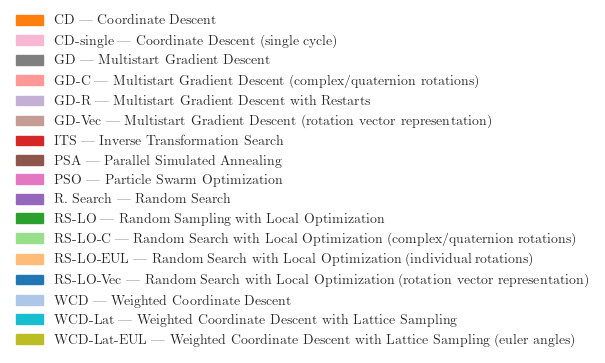

In [50]:
from matplotlib.patches import Patch
from utils.eval.vis import plt_setup_latex

W = plt_setup_latex()

# Sort algorithm keys alphabetically
sorted_shorts = sorted(fullname_dict.keys())

handles = [
    Patch(color=algorithm_colors[short], label=f"{short} — {fullname_dict[short]}")
    for short in sorted_shorts
]

# Plot legend in a separate figure
fig, ax = plt.subplots(figsize=(W, W*0.4))
ax.legend(
    handles=handles,
    loc='center',
    frameon=False,
    fontsize=10
)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "comparision_search_algorithms_legend.pdf"))
plt.savefig(os.path.join(figure_path, "comparision_search_algorithms_legend.pgf"))
plt.show()


In [51]:
from utils.eval.vis import plt_setup_latex

W=plt_setup_latex()

C:\Users\Lindner\AppData\Local\Temp\ipykernel_23208\1729506408.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


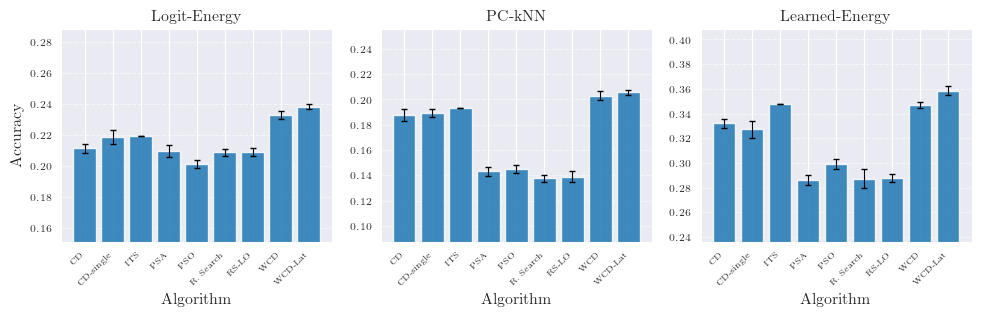

In [52]:
df_renamed["Accuracy_SE"] = pd.to_numeric(df_renamed["Accuracy_SE"], errors="coerce").fillna(0)

fig, axes = plt.subplots(
    1, len(problem_names_renamed),
    figsize=(W*2, W/1.5),
    constrained_layout=True
)
axes = axes if len(problem_names_renamed) > 1 else [axes]

for idx, (ax, problem) in enumerate(zip(axes, problem_names_renamed)):
    sub = df_renamed[df_renamed["Problem"] == problem].sort_values("Algorithm")
    algos = sub["Algorithm"].tolist()
    accs = sub["Accuracy"].to_numpy()
    ses = sub["Accuracy_SE"].to_numpy() *1.96

    x = np.arange(len(algos))

    # Directly map colors using algorithm_colors dict
    bar_colors = [algorithm_colors.get(a, (0.5, 0.5, 0.5)) for a in algos]

    ax.bar(
        x, accs, yerr=ses, capsize=2,
        alpha=0.85, ecolor='black', error_kw={'elinewidth': 0.8},
        color=None
    )

    ymin = max(0, accs.min() - 0.05)
    ymax = min(1, accs.max() + 0.05)
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(x)
    ax.set_xticklabels(algos, rotation=45, ha='right', fontsize=6)
    ax.set_title(problem)

    if idx == 0:
        ax.set_ylabel("Accuracy")
    ax.set_xlabel("Algorithm")
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

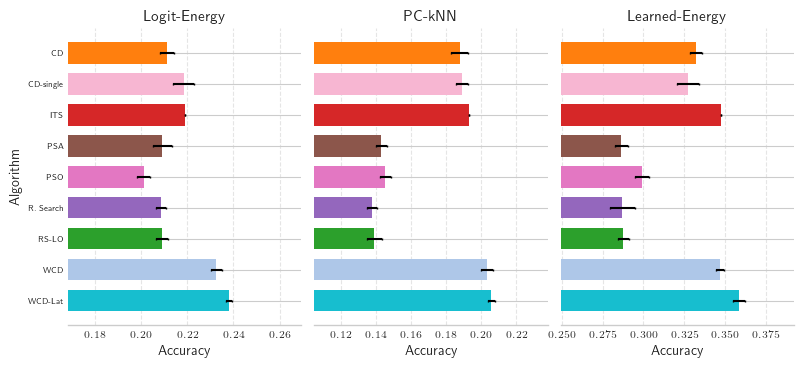

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

def plot_accuracy_bars(
    df,
    problem_column="Problem",
    algo_column="Algorithm",
    mean_column="Accuracy",
    se_column="Accuracy_SE",
    problem_names=None,
    algorithm_colors=None,
    figure_path=None,
    fig_width=None,
    fig_height=None,
    error_capsize=1.5,
    save_name="comparison_search_algorithms"
):
    """
    Plots horizontal bar charts of accuracy with error bars for each problem.
    Works for both individual problem scores and grouped scores.

    Parameters:
        df : pd.DataFrame
            Data containing algorithm performance.
        problem_column : str
            Column name for problems.
        algo_column : str
            Column name for algorithms.
        mean_column : str
            Column name for mean accuracy.
        se_column : str
            Column name for standard error.
        problem_names : list
            Ordered list of problems to plot. If None, all unique problems in df are used.
        algorithm_colors : dict
            Mapping from algorithm name to color (RGB tuple or string). Defaults to grey if missing.
        figure_path : str
            Directory to save the figure. If None, figure is not saved.
        fig_width, fig_height : float
            Figure dimensions. If None, defaults are computed automatically.
        error_capsize : float
            Capsize for error bars.
        save_name : str
            Base name for saved figure files (PDF & PGF).
    """
    plt.style.use("seaborn-v0_8-whitegrid")

    if problem_names is None:
        problem_names = df[problem_column].unique()

    if algorithm_colors is None:
        algorithm_colors = {}

    n_problems = len(problem_names)

    if fig_width is None:
        fig_width = 8
    if fig_height is None:
        fig_height = fig_width / max(2.2, n_problems / 3)

    fig, axes = plt.subplots(
        1, n_problems,
        figsize=(fig_width, fig_height),
        sharey=False
    )

    if n_problems == 1:
        axes = [axes]

    for idx, (ax, problem) in enumerate(zip(axes, problem_names)):
        sub = df[df[problem_column] == problem].sort_values(algo_column)

        algos = sub[algo_column].tolist()
        accs = sub[mean_column].to_numpy()
        ses = sub[se_column].to_numpy() *1.96
        y = np.arange(len(algos))

        colors = [algorithm_colors.get(a, (0.5, 0.5, 0.5)) for a in algos]

        ax.barh(
            y, accs, xerr=ses,
            capsize=error_capsize,
            color=colors,
            edgecolor="none",
            height=0.7,
            alpha=1,
            error_kw={'elinewidth': 1.5, 'ecolor': 'black', 'capsize': 1}
        )

        ax.set_yticks(y)
        if idx == 0:
            ax.set_yticklabels(algos, fontsize=6)
            ax.set_ylabel("Algorithm", fontsize=10)
        else:
            ax.set_yticklabels([])

        ax.invert_yaxis()  # first algorithm on top

        xmin = max(0, (accs - ses).min() - 0.03)
        xmax = min(1, (accs + ses).max() + 0.03)
        ax.set_xlim(xmin, xmax)

        ax.set_xlabel("Accuracy", fontsize=10)
        ax.set_title(problem, fontsize=11)
        ax.grid(True, axis='x', linestyle='--', alpha=0.5)
        sns.despine(ax=ax, left=True, bottom=False)

    plt.tight_layout(pad=0.5, w_pad=0.2)

    if figure_path is not None:
        os.makedirs(figure_path, exist_ok=True)
        plt.savefig(os.path.join(figure_path, f"{save_name}.pdf"))
        plt.savefig(os.path.join(figure_path, f"{save_name}.pgf"))

    plt.show()

plot_accuracy_bars(
    df=df_renamed,
    problem_names=problem_names_renamed,
    algorithm_colors=algorithm_colors,
    figure_path=figure_path
)


In [54]:
import numpy as np
import pandas as pd

def compute_grouped_scores(group):
    """
    Compute combined mean and SE across problems.
    """
    N = len(group)  # number of problems
    # Mean across problems
    mean_accuracy = group["Accuracy"].mean()

    # Variance of each problem mean: s_i^2 / n_i
    var_each = (group["Accuracy_STD"].to_numpy() ** 2) / group["Number_of_Runs"].to_numpy()

    # Combined SE across problems
    se_combined = np.sqrt(np.sum(var_each)) / N

    return pd.Series({
        "Grouped_Accuracy_Mean": mean_accuracy,
        "Grouped_Accuracy_SE": se_combined
    })

# Apply grouping
grouped_scores = df_renamed.groupby(["Algorithm", "Budget"]).apply(compute_grouped_scores).reset_index()
grouped_scores["Problem"] = "Grouped"
print(grouped_scores)

#plot grouped scores

   Algorithm  Budget  Grouped_Accuracy_Mean  Grouped_Accuracy_SE  Problem
0         CD      60               0.243633         1.186290e-03  Grouped
1  CD-single      60               0.244883         1.515363e-03  Grouped
2        ITS      60               0.253167         4.055582e-09  Grouped
3        PSA      60               0.212883         1.109569e-03  Grouped
4        PSO      60               0.215050         9.946308e-04  Grouped
5  R. Search      60               0.211100         1.450905e-03  Grouped
6      RS-LO      60               0.211867         1.003174e-03  Grouped
7        WCD      60               0.260883         8.359769e-04  Grouped
8    WCD-Lat      60               0.267417         7.532446e-04  Grouped


C:\Users\Lindner\AppData\Local\Temp\ipykernel_23208\3714703595.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_scores = df_renamed.groupby(["Algorithm", "Budget"]).apply(compute_grouped_scores).reset_index()


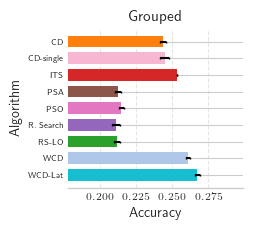

In [55]:
plot_accuracy_bars(
    df=grouped_scores,  # DataFrame with Grouped_Accuracy_Mean & Grouped_Accuracy_SE
    mean_column="Grouped_Accuracy_Mean",
    se_column="Grouped_Accuracy_SE",
    problem_names=None,  # will use all problems if None
    algorithm_colors=algorithm_colors,
    figure_path=figure_path,
    save_name="grouped_comparison_search_algorithms",
    fig_width=W/2,
    fig_height=W/2.2,
)


In [56]:
#plot grouped accuracy across problems


In [57]:
def analyze_run_results(results_list):
    """
    Computes summary statistics per algorithm for each problem.
    Uses all runs per algorithm.
    Normalizes errors per sample using min–max scaling across all runs & algorithms.
    Frobenius distance is computed against the best run per sample (lowest raw error).
    Checks for consistency of true labels and includes predicted labels from the best run.
    """
    import numpy as np
    from collections import defaultdict

    results_by_problem = defaultdict(list)
    for entry in results_list:
        results_by_problem[entry["Problem"]].append(entry)

    problem_summaries = {}

    for problem, entries in results_by_problem.items():
        # Collect all errors, matrices, and labels
        all_errors, all_mats, algo_labels = [], [], []
        all_true_labels, all_pred_labels = [], []
        run_metadata = []

        for entry in entries:
            algo = ALGO_RENAME.get(entry["Algorithm"], entry["Algorithm"])
            problem_name = PROBLEM_RENAME.get(entry["Problem"], entry["Problem"])

            entry["Algorithm"] = algo
            entry["Problem"] = problem_name

            res = entry["metrics"]
            runs = res.get("per_run", [res])

            for run_idx, run in enumerate(runs):
                if "per_sample_errors" not in run or "per_sample_matrices" not in run:
                    continue

                errs = np.array(run["per_sample_errors"], dtype=float)
                mats = run["per_sample_matrices"]

                all_errors.append(errs)
                all_mats.append(mats)
                algo_labels.append(algo)
                run_metadata.append({'algo': algo, 'run_idx_in_algo': run_idx})

                if "per_sample_true_labels" in run:
                    all_true_labels.append(run["per_sample_true_labels"])
                if "per_sample_pred_labels" in run:
                    all_pred_labels.append(run["per_sample_pred_labels"])

        if not all_errors:
            continue

        # Check for label consistency
        labels_available = len(all_true_labels) == len(all_errors)
        if labels_available and len(all_true_labels) > 1:
            first_labels = tuple(all_true_labels[0])
            for i, labels in enumerate(all_true_labels[1:], 1):
                if tuple(labels) != first_labels:
                    meta0 = run_metadata[0]
                    meta_i = run_metadata[i]
                    raise ValueError(
                        f"Inconsistent 'per_sample_true_labels' in problem '{problem}'. "
                        f"Run {meta0['run_idx_in_algo']} of algorithm '{meta0['algo']}' does not match "
                        f"run {meta_i['run_idx_in_algo']} of algorithm '{meta_i['algo']}'."
                    )

        all_errors = np.stack(all_errors)
        eps = 1e-12
        num_samples = all_errors.shape[1]
        num_runs = all_errors.shape[0]

        # Per-sample min/max across all runs and algorithms
        min_errors = np.nanmin(all_errors, axis=0)
        max_errors = np.nanmax(all_errors, axis=0)
        denom = max_errors - min_errors + eps

        # Best run index per sample (lowest error)
        best_run_idx_per_sample = np.nanargmin(
            np.where(np.isnan(all_errors), np.inf, all_errors), axis=0
        )
        best_mats = [all_mats[idx][j] for j, idx in enumerate(best_run_idx_per_sample)]

        # Extract best predicted labels if available
        best_pred_labels = None
        pred_labels_available = len(all_pred_labels) == len(all_errors)
        if pred_labels_available:
            best_pred_labels = [
                all_pred_labels[idx][j] for j, idx in enumerate(best_run_idx_per_sample)
            ]

        # Vectorized relative error computation for all runs
        relative_errors = (all_errors - min_errors[None, :]) / denom[None, :]

        # Pre-compute Frobenius distances for all runs at once
        # Convert all matrices to numpy arrays and stack them
        try:
            # Try to stack all matrices if they have the same shape
            best_mats_array = np.array(best_mats, dtype=float)  # Shape: (num_samples, ...)

            # Stack all run matrices: shape (num_runs, num_samples, ...)
            all_mats_stacked = []
            for run_mats in all_mats:
                run_mats_array = np.array(run_mats[:num_samples], dtype=float)
                all_mats_stacked.append(run_mats_array)
            all_mats_stacked = np.array(all_mats_stacked)  # (num_runs, num_samples, ...)

            # Compute Frobenius distances vectorized
            # Diff shape: (num_runs, num_samples, ...)
            diff = all_mats_stacked - best_mats_array[None, :, ...]

            # Flatten last dimensions and compute norms
            shape = diff.shape
            diff_flat = diff.reshape(shape[0], shape[1], -1)  # (num_runs, num_samples, flattened)
            best_flat = best_mats_array.reshape(shape[1], -1)  # (num_samples, flattened)

            # Compute norms: (num_runs, num_samples)
            diff_norms = np.linalg.norm(diff_flat, axis=2)
            best_norms = np.linalg.norm(best_flat, axis=1)  # (num_samples,)

            # Frobenius distances: (num_runs, num_samples)
            frobenius_distances = diff_norms / (best_norms[None, :] + eps)

            # Mask out invalid values (NaN errors or infinite Frobenius)
            valid_mask = ~np.isnan(all_errors) & np.isfinite(frobenius_distances)
            frobenius_distances = np.where(valid_mask, frobenius_distances, np.nan)

            matrices_vectorized = True

        except (ValueError, TypeError):
            # Fall back to slower method if matrices have different shapes
            matrices_vectorized = False
            frobenius_distances = np.full((num_runs, num_samples), np.nan)

            for run_idx in range(num_runs):
                mats = all_mats[run_idx]
                for j in range(min(num_samples, len(mats))):
                    if np.isnan(all_errors[run_idx, j]):
                        continue

                    try:
                        ma = np.array(mats[j], dtype=float)
                        mb = np.array(best_mats[j], dtype=float)

                        if ma.shape == mb.shape and not (np.any(np.isnan(ma)) or np.any(np.isnan(mb))):
                            frob = np.linalg.norm(ma - mb) / (np.linalg.norm(mb) + eps)
                            if np.isfinite(frob):
                                frobenius_distances[run_idx, j] = frob
                    except:
                        continue

        # Compute per-algorithm statistics
        summary = {}
        unique_algos = sorted(set(algo_labels))

        for algo in unique_algos:
            # Get indices of all runs for this algorithm
            algo_mask = np.array([a == algo for a in algo_labels])

            # Vectorized relative errors for this algorithm
            algo_rel_errs = relative_errors[algo_mask]  # Shape: (num_algo_runs, num_samples)
            algo_frobs = frobenius_distances[algo_mask]  # Shape: (num_algo_runs, num_samples)

            # Average across samples for each run (ignoring NaNs)
            run_avg_rel_errs = np.nanmean(algo_rel_errs, axis=1)
            run_avg_rel_errs = run_avg_rel_errs[~np.isnan(run_avg_rel_errs)]

            run_avg_frobs = np.nanmean(algo_frobs, axis=1)
            run_avg_frobs = run_avg_frobs[~np.isnan(run_avg_frobs)]

            num_runs = len(run_avg_rel_errs)

            summary[algo] = {
                "mean_relative_error": float(np.mean(run_avg_rel_errs)) if len(run_avg_rel_errs) > 0 else None,
                "std_relative_error": float(np.std(run_avg_rel_errs, ddof=1)) if num_runs > 1 else None,
                "mean_frobenius": float(np.mean(run_avg_frobs)) if len(run_avg_frobs) > 0 else None,
                "std_frobenius": float(np.std(run_avg_frobs, ddof=1)) if len(run_avg_frobs) > 1 else None,
                "se_relative_error": float(np.std(run_avg_rel_errs, ddof=1) / np.sqrt(num_runs)) if num_runs > 1 else None,
                "se_frobenius": float(np.std(run_avg_frobs, ddof=1) / np.sqrt(num_runs)) if len(run_avg_frobs) > 1 else None,
                "num_runs": num_runs
            }

        problem_summaries[problem] = {
            "num_datapoints": num_samples,
            "num_runs": all_errors.shape[0],
            "algorithms": summary,
            "true_labels": all_true_labels[0] if labels_available else None,
            "best_predicted_labels": best_pred_labels,
        }

    return problem_summaries




import json
import os

results_list = []
for budget in budgets:
    for algo in all_algos:
        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        for method_name in problem_names:
            eval_path = os.path.join(algo_dir, f"eval_{method_name}.json")
            if os.path.exists(eval_path):
                with open(eval_path, "r") as f:
                    metrics = json.load(f)
                results_list.append({
                    "Algorithm": algo,
                    "Problem": method_name,
                    "metrics": metrics
                })






In [58]:
def analyze_run_results_with_budget(results_list):
    """
    Computes summary statistics per algorithm and budget for each problem.
    Uses global min-max normalization across all budgets, runs, and algorithms.
    Frobenius distance is computed against the global best run per sample.
    """
    import numpy as np
    from collections import defaultdict

    # Apply renaming first, then group
    for entry in results_list:
        algo = ALGO_RENAME.get(entry["Algorithm"], entry["Algorithm"])
        problem_name = PROBLEM_RENAME.get(entry["Problem"], entry["Problem"])
        entry["Algorithm"] = algo
        entry["Problem"] = problem_name

    results_by_problem = defaultdict(list)
    for entry in results_list:
        results_by_problem[entry["Problem"]].append(entry)

    problem_summaries = {}

    for problem, entries in results_by_problem.items():
        # First pass: collect all errors globally to find min/max and best run per sample
        all_errors_global = []
        all_mats_global = []
        metadata_global = []
        all_true_labels, all_pred_labels = [], []

        for entry in entries:
            algo = entry["Algorithm"]
            problem_name = entry["Problem"]
            budget = entry["Budget"]

            res = entry["metrics"]
            runs = res.get("per_run", [res])

            for run_idx, run in enumerate(runs):
                if "per_sample_errors" not in run or "per_sample_matrices" not in run:
                    continue

                errs = np.array(run["per_sample_errors"], dtype=float)
                mats = run["per_sample_matrices"]

                all_errors_global.append(errs)
                all_mats_global.append(mats)
                metadata_global.append({
                    'algo': algo,
                    'budget': budget,
                    'run_idx': run_idx
                })

                if "per_sample_true_labels" in run:
                    all_true_labels.append(run["per_sample_true_labels"])
                if "per_sample_pred_labels" in run:
                    all_pred_labels.append(run["per_sample_pred_labels"])

        if not all_errors_global:
            continue

        array_labels = np.array(all_true_labels)
        assert np.all(array_labels == array_labels[0]), "Rows are not equal"

        all_errors_global = np.stack(all_errors_global)
        eps = 1e-12
        num_samples = all_errors_global.shape[1]

        # Global min/max across all budgets and algorithms
        min_errors = np.nanmin(all_errors_global, axis=0)
        max_errors = np.nanmax(all_errors_global, axis=0)
        denom = max_errors - min_errors + eps

        # Global best run per sample
        best_run_idx_per_sample = np.nanargmin(
            np.where(np.isnan(all_errors_global), np.inf, all_errors_global), axis=0
        )
        best_mats = [all_mats_global[idx][j] for j, idx in enumerate(best_run_idx_per_sample)]

        # Best predicted labels
        best_pred_labels = None
        pred_labels_available = len(all_pred_labels) == len(all_errors_global)
        if pred_labels_available:
            best_pred_labels = [
                all_pred_labels[idx][j] for j, idx in enumerate(best_run_idx_per_sample)
            ]

        # Vectorized relative error computation
        relative_errors_global = (all_errors_global - min_errors[None, :]) / denom[None, :]

        # Pre-compute Frobenius distances

        best_mats_array = np.array(best_mats, dtype=float)
        all_mats_stacked = []
        for run_mats in all_mats_global:
            run_mats_array = np.array(run_mats[:num_samples], dtype=float)
            all_mats_stacked.append(run_mats_array)
        all_mats_stacked = np.array(all_mats_stacked)

        diff = all_mats_stacked - best_mats_array[None, :, ...]
        shape = diff.shape
        diff_flat = diff.reshape(shape[0], shape[1], -1)
        best_flat = best_mats_array.reshape(shape[1], -1)

        diff_norms = np.linalg.norm(diff_flat, axis=2)
        best_norms = np.linalg.norm(best_flat, axis=1)

        frobenius_distances_global = diff_norms / (best_norms[None, :] + eps)
        valid_mask = ~np.isnan(all_errors_global) & np.isfinite(frobenius_distances_global)
        frobenius_distances_global = np.where(valid_mask, frobenius_distances_global, np.nan)



        # Second pass: organize by budget and algorithm
        summary_by_budget = defaultdict(dict)

        for entry in entries:
            algo = entry["Algorithm"]
            budget = entry["Budget"]
            res = entry["metrics"]
            runs = res.get("per_run", [res])

            # Find indices for this algo+budget combination
            indices = [i for i, meta in enumerate(metadata_global)
                      if meta['algo'] == algo and meta['budget'] == budget]

            if not indices:
                continue

            algo_rel_errs = relative_errors_global[indices]
            algo_frobs = frobenius_distances_global[indices]

            run_avg_rel_errs = np.nanmean(algo_rel_errs, axis=1)
            run_avg_rel_errs = run_avg_rel_errs[~np.isnan(run_avg_rel_errs)]

            run_avg_frobs = np.nanmean(algo_frobs, axis=1)
            run_avg_frobs = run_avg_frobs[~np.isnan(run_avg_frobs)]

            num_runs = len(run_avg_rel_errs)

            summary_by_budget[budget][algo] = {
                "mean_relative_error": float(np.mean(run_avg_rel_errs)) if len(run_avg_rel_errs) > 0 else None,
                "std_relative_error": float(np.std(run_avg_rel_errs, ddof=1)) if num_runs > 1 else 0,
                "mean_frobenius": float(np.mean(run_avg_frobs)) if len(run_avg_frobs) > 0 else None,
                "std_frobenius": float(np.std(run_avg_frobs, ddof=1)) if num_runs > 1 else 0,
                "se_relative_error": float(np.std(run_avg_rel_errs, ddof=1) / np.sqrt(num_runs)) if num_runs > 1 else 0,
                "se_frobenius": float(np.std(run_avg_frobs, ddof=1) / np.sqrt(num_runs)) if len(run_avg_frobs) > 1 else 0,
                "num_runs": num_runs
            }

        problem_summaries[problem] = {
            "num_datapoints": num_samples,
            "budgets": dict(summary_by_budget),
            "true_labels": all_true_labels[0],
            "best_predicted_labels": best_pred_labels,
        }

    return problem_summaries
def analyze_run_results(results_list):
    """
    Wrapper around analyze_run_results_with_budget that assumes a single budget
    (real or dummy) for all results. It ensures correct calculation of run statistics
    (mean, std, and number of individual runs) by extracting the summary directly
    from the single budget group computed by the inner function.
    """
    import numpy as np
    # defaultdict is not needed here, but kept if you use it elsewhere.

    # --- Step 1: Add Dummy Budget if Missing ---
    budget_added = False
    if results_list and "Budget" not in results_list[0]:
        for entry in results_list:
            if "Budget" not in entry:
                entry["Budget"] = 0  # dummy budget
        budget_added = True

    # --- Step 2: Call the Budget-Aware Function ---
    # This computes the summary for the single (real or dummy) budget group.
    full_summary = analyze_run_results_with_budget(results_list)

    # --- Step 3: Extract the Single Budget Summary ---
    collapsed_summary = {}

    for problem, summary in full_summary.items():
        budgets = summary["budgets"]

        # Since we assume a single budget, we must find that one budget key.
        if not budgets:
            # Should not happen if data exists, but a safe check
            algo_summary = {}
        else:
            # Get the key for the one and only budget group (e.g., 0 or 100).
            budget_key = next(iter(budgets))
            # This directly extracts the summary containing the mean/std over ALL individual runs
            # and the correct total 'num_runs' (e.g., 5).
            algo_summary = budgets[budget_key]

        collapsed_summary[problem] = {
            "num_datapoints": summary["num_datapoints"],
            "true_labels": summary.get("true_labels"),
            "best_predicted_labels": summary.get("best_predicted_labels"),
            "algorithms": algo_summary,
        }

    # --- Step 4: Cleanup ---
    if budget_added:
        for entry in results_list:
            if "Budget" in entry and entry["Budget"] == 0:
                del entry["Budget"]

    return collapsed_summary





In [59]:
analysis = analyze_run_results(results_list)

In [60]:
analysis

{'Logit-Energy': {'num_datapoints': 2000,
  'true_labels': [28,
   77,
   114,
   98,
   241,
   136,
   231,
   152,
   115,
   149,
   169,
   50,
   74,
   63,
   58,
   36,
   54,
   9,
   237,
   219,
   137,
   78,
   157,
   229,
   60,
   242,
   164,
   140,
   234,
   149,
   224,
   8,
   90,
   224,
   69,
   212,
   245,
   38,
   81,
   190,
   98,
   71,
   236,
   137,
   2,
   57,
   134,
   132,
   184,
   1,
   151,
   239,
   113,
   199,
   1,
   224,
   108,
   68,
   22,
   173,
   108,
   13,
   117,
   32,
   75,
   230,
   197,
   22,
   161,
   80,
   81,
   225,
   235,
   212,
   94,
   70,
   24,
   245,
   127,
   225,
   128,
   139,
   213,
   84,
   88,
   2,
   176,
   185,
   75,
   138,
   16,
   69,
   21,
   220,
   9,
   70,
   170,
   33,
   2,
   176,
   118,
   153,
   189,
   106,
   7,
   120,
   197,
   14,
   6,
   194,
   74,
   95,
   187,
   1,
   209,
   111,
   53,
   84,
   126,
   207,
   91,
   235,
   223,
   1,
   101,
   110,
  

In [61]:
# Print summary per problem
for problem, pdata in analysis.items():
    print(f"\n=== Problem: {problem} ===")
    #print(f"Analyzed {pdata['num_datapoints']} datapoints across {pdata['num_runs']} runs")
    for algo, stats in pdata["algorithms"].items():
        print(f"  Algorithm: {algo}")
        print(f"    Mean relative error:   {stats['mean_relative_error']:.6f} ± {stats['std_relative_error']:.6f}")
        print(f"    Mean Frobenius dist.:  {stats['mean_frobenius']:.6f} ± {stats['std_frobenius']:.6f}")


=== Problem: Logit-Energy ===
  Algorithm: RS-LO
    Mean relative error:   0.456025 ± 0.003888
    Mean Frobenius dist.:  0.732808 ± 0.013459
  Algorithm: PSA
    Mean relative error:   0.471172 ± 0.003285
    Mean Frobenius dist.:  0.787056 ± 0.009831
  Algorithm: PSO
    Mean relative error:   0.400070 ± 0.007281
    Mean Frobenius dist.:  0.761102 ± 0.010806
  Algorithm: CD-single
    Mean relative error:   0.440392 ± 0.006653
    Mean Frobenius dist.:  0.770758 ± 0.009432
  Algorithm: WCD
    Mean relative error:   0.402049 ± 0.004630
    Mean Frobenius dist.:  0.724506 ± 0.004415
  Algorithm: ITS
    Mean relative error:   0.404386 ± 0.000000
    Mean Frobenius dist.:  0.745091 ± 0.000000
  Algorithm: R. Search
    Mean relative error:   0.456001 ± 0.003276
    Mean Frobenius dist.:  0.737348 ± 0.006836
  Algorithm: WCD-Lat
    Mean relative error:   0.380660 ± 0.004012
    Mean Frobenius dist.:  0.708472 ± 0.006301
  Algorithm: CD
    Mean relative error:   0.443826 ± 0.003129


In [62]:
import numpy as np

for entry in results_list:
    algo = entry["Algorithm"]
    prob = entry["Problem"]
    metrics = entry["metrics"]

    runs = metrics.get("per_run", [metrics])
    for run_idx, run in enumerate(runs):
        mats = run.get("per_sample_matrices", [])
        for j, m in enumerate(mats):
            m_arr = np.array(m, dtype=float)
            if np.any(np.isnan(m_arr)):
                print(f"NaN matrix found: Problem={prob}, Algo={algo}, Run={run_idx}, Sample={j}")
                break

In [63]:
import pandas as pd

def analysis_to_df(analysis):
    """
    Convert the nested 'analysis' dict from analyze_run_results
    into a long DataFrame suitable for plotting.
    """
    rows = []
    for problem, pdata in analysis.items():
        for algo, stats in pdata["algorithms"].items():
            rows.append({
                "Problem": problem,
                "Algorithm": algo,
                "mean_relative_error": stats.get("mean_relative_error"),
                "se_relative_error": stats.get("se_relative_error"),
                "std_relative_error": stats.get("std_relative_error"),
                "mean_frobenius": stats.get("mean_frobenius"),
                "se_frobenius": stats.get("se_frobenius"),
                "std_frobenius": stats.get("std_frobenius"),
                "num_runs": stats.get("num_runs"),
                "num_datapoints": pdata.get("num_datapoints")
            })
    df = pd.DataFrame(rows)
    return df


In [64]:
df_analysis = analysis_to_df(analysis)
df_analysis

,Problem,Algorithm,mean_relative_error,se_relative_error,std_relative_error,mean_frobenius,se_frobenius,std_frobenius,num_runs,num_datapoints
0,Logit-Energy,RS-LO,0.456025,1.229581e-03,3.888277e-03,0.732808,4.255958e-03,1.345852e-02,10,2000
1,Logit-Energy,PSA,0.471172,1.038792e-03,3.284950e-03,0.787056,3.108790e-03,9.830856e-03,10,2000
2,Logit-Energy,PSO,0.400070,2.302332e-03,7.280612e-03,0.761102,3.417236e-03,1.080625e-02,10,2000
3,Logit-Energy,CD-single,0.440392,2.103961e-03,6.653310e-03,0.770758,2.982718e-03,9.432181e-03,10,2000
4,Logit-Energy,WCD,0.402049,1.464228e-03,4.630296e-03,0.724506,1.396231e-03,4.415271e-03,10,2000
5,Logit-Energy,ITS,0.404386,4.047721e-08,1.280002e-07,0.745091,0.000000e+00,0.000000e+00,10,2000
6,Logit-Energy,R. Search,0.456001,1.035845e-03,3.275628e-03,0.737348,2.161851e-03,6.836373e-03,10,2000
7,Logit-Energy,WCD-Lat,0.380660,1.268660e-03,4.011854e-03,0.708472,1.992447e-03,6.300671e-03,10,2000
8,Logit-Energy,CD,0.443826,9.895204e-04,3.129138e-03,0.767927,1.929346e-03,6.101128e-03,10,2000
9,PC-kNN,RS-LO,0.438135,1.712582e-03,5.415661e-03,0.792298,2.578111e-03,8.152703e-03,10,2000


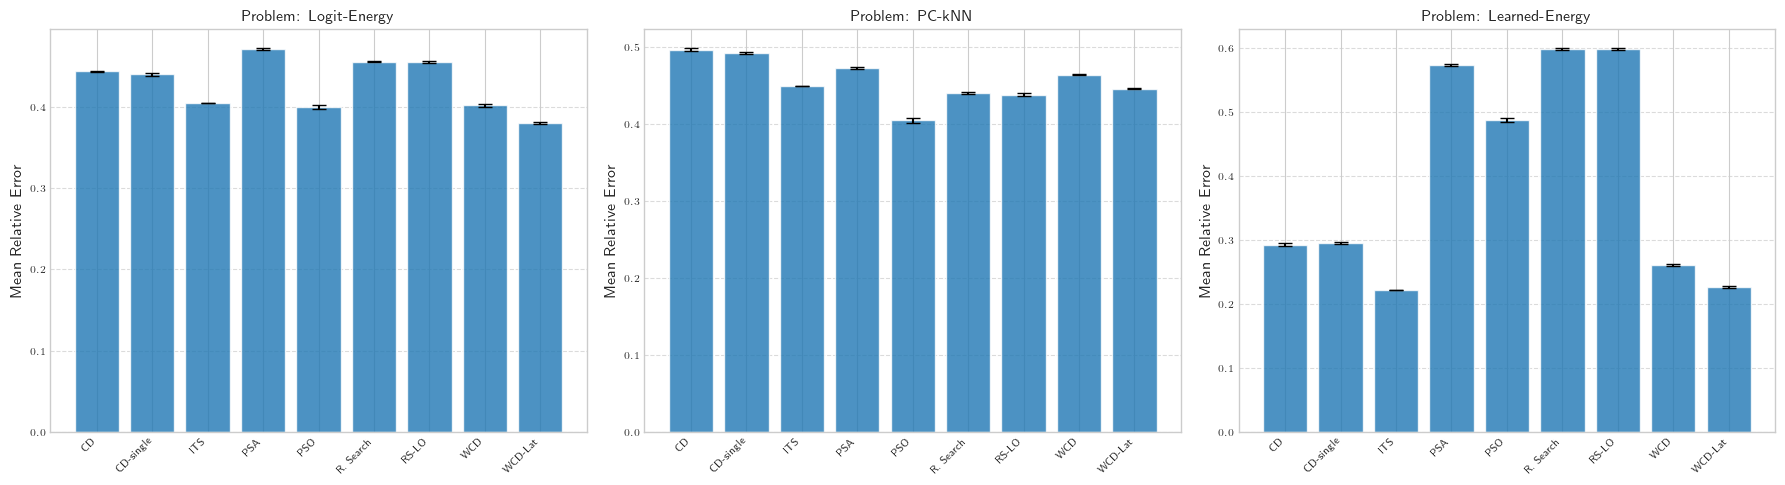

In [65]:
import matplotlib.pyplot as plt
import numpy as np

def plot_df_analysis(df, metric="mean_relative_error", error_col=None):
    """
    Plot results from a flattened analysis DataFrame.

    df: pd.DataFrame with columns ['Problem', 'Algorithm', metric, error_col]
    metric: which mean to plot ('mean_relative_error' or 'mean_frobenius')
    error_col: which column contains the error bars (SEM)
    """
    if error_col is None:
        error_col = "se_relative_error" if metric == "mean_relative_error" else "se_frobenius"

    problem_names = df["Problem"].unique()
    num_problems = len(problem_names)

    fig, axes = plt.subplots(1, num_problems, figsize=(6 * num_problems, 5), squeeze=False)

    for ax, problem in zip(axes[0], problem_names):
        sub = df[df["Problem"] == problem].sort_values("Algorithm")
        algos = sub["Algorithm"].tolist()
        means = sub[metric].tolist()
        errors = sub[error_col].tolist()

        x = np.arange(len(algos))
        ax.bar(x, means, yerr=errors, capsize=5, alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(algos, rotation=45, ha="right")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_title(f"Problem: {problem}")
        ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_df_analysis(df_analysis, metric="mean_relative_error")

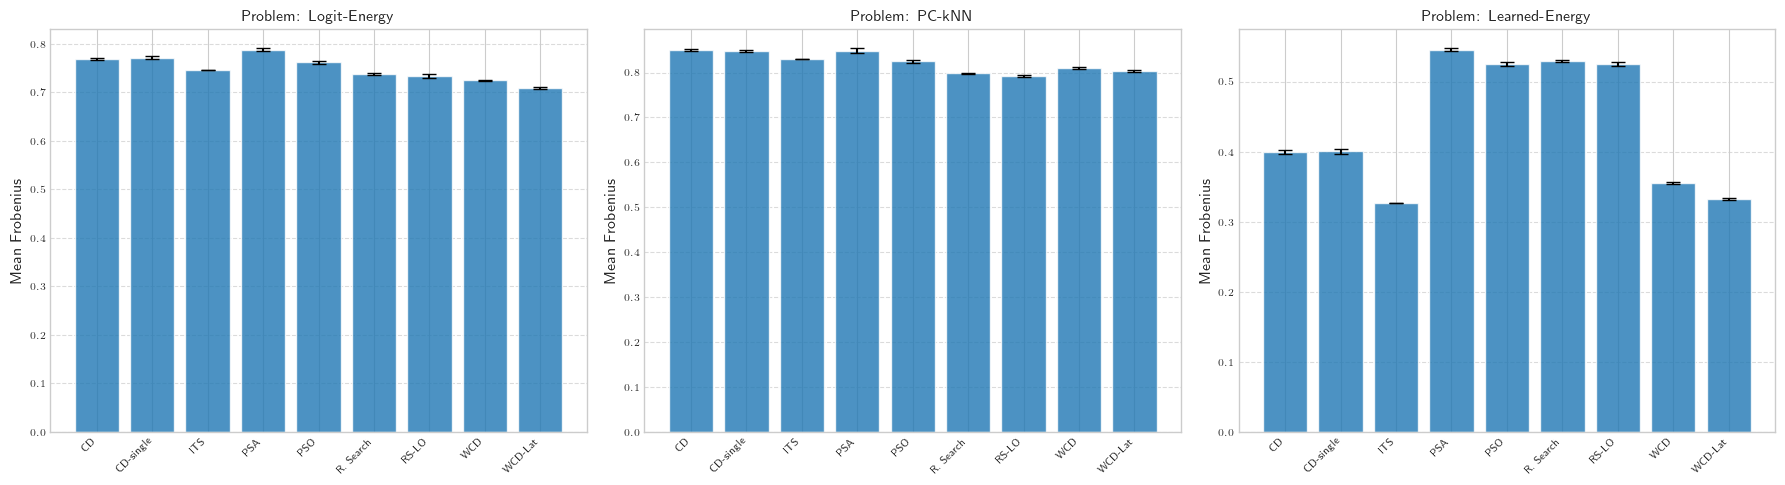

In [66]:
plot_df_analysis(df_analysis, metric="mean_frobenius")

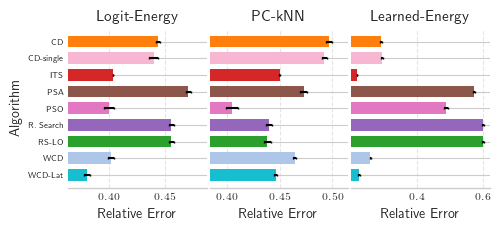

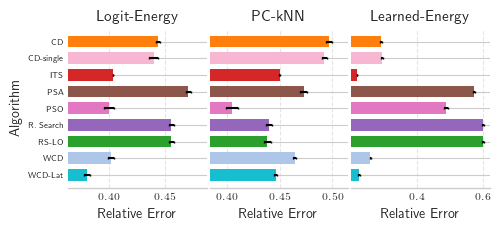

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import pandas as pd

def plot_analysis_with_sem(analysis, algorithm_colors, metric="mean_relative_error", W=8, savepath=None):
    """
    Plot per-problem results with horizontal bars and SEM error bars.
    Total figure width is W, height is W/2.2.

    Parameters:
    -----------
    analysis : dict or pd.DataFrame
        Dictionary from analyze_run_results OR a flattened DataFrame with columns:
        ['Problem', 'Algorithm', metric, se_relative_error, se_frobenius']
    algorithm_colors : dict
        Mapping from algorithm name to RGB color tuple
    metric : str
        Which mean to plot ("mean_relative_error" or "mean_frobenius")
    W : float
        Total figure width in inches
    savepath : str
        Path to save the figure (optional)
    """
    # Determine if input is dict or DataFrame
    if isinstance(analysis, dict):
        problem_names = list(analysis.keys())
    elif isinstance(analysis, pd.DataFrame):
        problem_names = analysis["Problem"].unique()
    else:
        raise ValueError("analysis must be a dict or a pandas DataFrame")

    num_problems = len(problem_names)
    if isinstance(W, (int, float)):
        fig_width = W
        fig_height = W / 2.2  # proportional height
    else:
        fig_width, fig_height = W

    fig, axes = plt.subplots(
        1, num_problems,
        figsize=(fig_width, fig_height),
        sharey=False,
        squeeze=False
    )
    axes = axes[0]  # flatten if necessary

    # Metric label
    metric_label = metric.replace("_", " ").title()
    if metric == "mean_relative_error":
        metric_label = "Relative Error"
    elif metric == "mean_frobenius":
        metric_label = "Frobenius Error"

    for idx, ax in enumerate(axes):
        problem = problem_names[idx]

        if isinstance(analysis, dict):
            pdata = analysis[problem]
            algos = sorted(pdata["algorithms"].keys())
            means = []
            sems = []
            for algo in algos:
                stats = pdata["algorithms"][algo]
                means.append(stats[metric])
                sem_val = (
                    stats["se_relative_error"] if metric == "mean_relative_error"
                    else stats["se_frobenius"]
                )
                sems.append(sem_val)
        else:  # DataFrame
            sub = analysis[analysis["Problem"] == problem].sort_values("Algorithm")
            algos = sub["Algorithm"].tolist()
            means = sub[metric].tolist()
            sems = sub["se_relative_error"].tolist() if metric == "mean_relative_error" else sub["se_frobenius"].tolist()

        y = np.arange(len(algos))
        colors = [algorithm_colors.get(a, (0.5, 0.5, 0.5)) for a in algos]
        sems = [sem*1.96 for sem in sems]
        ax.barh(
            y, means, xerr=sems,
            capsize=1.5,
            color=colors,
            edgecolor="none",
            height=0.7,
            alpha=1,
            error_kw={'elinewidth': 1.5, 'ecolor': 'black', 'capsize': 1}
        )

        ax.set_yticks(y)
        if idx == 0:
            ax.set_yticklabels(algos, fontsize=6)
            ax.set_ylabel("Algorithm", fontsize=10)
        else:
            ax.set_yticklabels([])

        ax.invert_yaxis()
        means_arr = np.array(means)
        sems_arr = np.array([s if s is not None else 0 for s in sems])
        xmin = max(0, (means_arr - sems_arr).min() - 0.03 * means_arr.max())
        xmax = (means_arr + sems_arr).max() + 0.03 * means_arr.max()
        ax.set_xlim(xmin, xmax)

        ax.set_xlabel(metric_label, fontsize=10)
        ax.set_title(f"{problem}", fontsize=11)
        ax.grid(True, axis='x', linestyle='--', alpha=0.5)
        sns.despine(ax=ax, left=True, bottom=False)

    plt.tight_layout(pad=0.5, w_pad=0.2)
    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath)
    plt.show()


# --- Usage: pass total width W ---
path_pdf = os.path.join(figure_path, "mean_relative_error.pdf")
plot_analysis_with_sem(analysis, algorithm_colors, metric="mean_relative_error", W=W, savepath=path_pdf)

path_pgf = os.path.join(figure_path, "mean_relative_error.pgf")
plot_analysis_with_sem(analysis, algorithm_colors, metric="mean_relative_error", W=W, savepath=path_pgf)


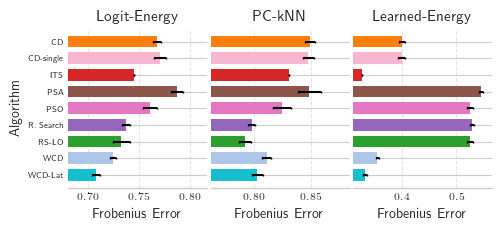

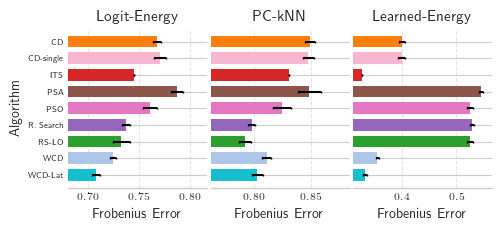

In [68]:
path = os.path.join(figure_path, f"mean_frobenius.pdf")
plot_analysis_with_sem(analysis, algorithm_colors, metric="mean_frobenius", savepath=path, W=W)
path = os.path.join(figure_path, f"mean_frobenius.pgf")
plot_analysis_with_sem(analysis, algorithm_colors, metric="mean_frobenius", savepath=path, W=W)

In [69]:
def compute_grouped_scores(df):
    """
    Aggregates per-algorithm statistics across all problems for both metrics.
    """
    # Use agg instead of apply to avoid DeprecationWarning
    grouped = df.groupby("Algorithm").agg(
        mean_relative_error=("mean_relative_error","mean"),
        se_relative_error=("se_relative_error", lambda x: np.sqrt(np.sum((x*np.sqrt(df.loc[x.index,'num_runs']))**2)/df.loc[x.index,'num_runs'].sum())/len(x)),
        mean_frobenius=("mean_frobenius","mean"),
        se_frobenius=("se_frobenius", lambda x: np.sqrt(np.sum((x*np.sqrt(df.loc[x.index,'num_runs']))**2)/df.loc[x.index,'num_runs'].sum())/len(x))
    ).reset_index()
    grouped["Problem"] = "Grouped"
    return grouped

df_analysis_grouped = compute_grouped_scores(df_analysis)

In [70]:
df_analysis_grouped

,Algorithm,mean_relative_error,se_relative_error,mean_frobenius,se_frobenius,Problem
0,CD,0.411290,0.000512,0.672473,0.000796,Grouped
1,CD-single,0.409479,0.000555,0.672984,0.000974,Grouped
2,ITS,0.358619,0.000007,0.634417,0.000008,Grouped
3,PSA,0.505836,0.000475,0.727088,0.001212,Grouped
4,PSO,0.430890,0.000992,0.703560,0.001140,Grouped
5,R. Search,0.498160,0.000476,0.688217,0.000615,Grouped
6,RS-LO,0.497691,0.000462,0.683207,0.001088,Grouped
7,WCD,0.375826,0.000369,0.630316,0.000558,Grouped
8,WCD-Lat,0.351209,0.000360,0.614636,0.000676,Grouped


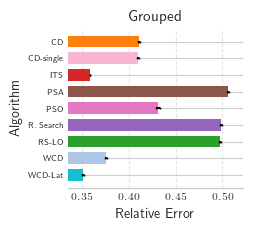

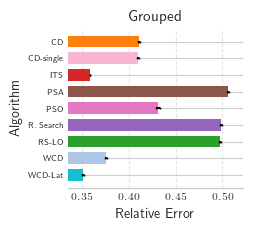

In [71]:
#now plot grouped scores with sem
plot_analysis_with_sem(
    df_analysis_grouped,
    algorithm_colors,
    metric="mean_relative_error",
    savepath=os.path.join(figure_path, "grouped_mean_relative_error.pdf"),
    W=(W/2,W/2.2)
)
plot_analysis_with_sem(
    df_analysis_grouped,
    algorithm_colors,
    metric="mean_relative_error",
    savepath=os.path.join(figure_path, "grouped_mean_relative_error.pgf"),
    W=(W/2,W/2.2)
)

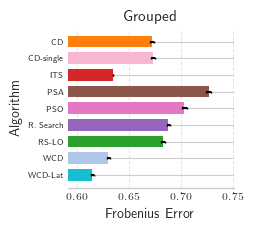

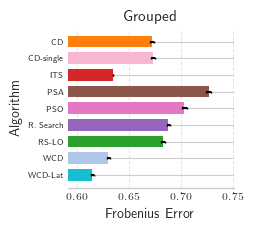

In [72]:
plot_analysis_with_sem(
    df_analysis_grouped,
    algorithm_colors,
    metric="mean_frobenius",
    savepath=os.path.join(figure_path, "grouped_mean_frobenius.pdf"),
    W=(W/2,W/2.2),
)
plot_analysis_with_sem(
    df_analysis_grouped,
    algorithm_colors,
    metric="mean_frobenius",
    savepath=os.path.join(figure_path, "grouped_mean_frobenius.pgf"),
    W=(W/2,W/2.2),
)

In [73]:
for budget in budgets:
    print(f"\n=== Best Params Summary | Budget: {budget} ===")
    for algo in all_algos:
        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        param_path = os.path.join(algo_dir, "best.yml")

        if os.path.exists(param_path):
            stored_params = load_params(param_path)
            print(f"\n--- {algo} ---")
            for k, v in stored_params.items():
                print(f"{k}: {v}")
        else:
            print(f"\n--- {algo} ---")
            print("No stored params found.")



=== Best Params Summary | Budget: 60 ===

--- shgo ---
grad_weight: 99999999
shgo_acceptance_criterion: step
shgo_initial_samples: 60
shgo_local_opt: adam
shgo_local_runs: 1
shgo_local_steps: 0
shgo_lr: 0.039015698711496447
shgo_selection_method: topk

--- parallel_sa ---
psa_cooling: 0.8148556105583249
psa_init_temp: 1.6277029817041653
psa_max_iterations: 11
psa_neighbor_hood_size: 0.5918712675673384
psa_parallel_runs: 5
psa_reinit_amount: 0.0
psa_reinit_interval: 9999999999999

--- pso ---
pso_c1: 2.6822601698348647
pso_c2: 1.1378683129707379
pso_clamp_velocity: False
pso_steps: 5
pso_swarm_size: 10
pso_vmax_scale: 0.4173348244449122
pso_w: 0.8929385524811997

--- cd ---
No stored params found.

--- wcd ---
wcd_base_samples: 7
wcd_dim_estimate: 5
wcd_first_dim_factor: 4
wcd_rounds: 1

--- its ---
its_change_of_mind: score
its_gaussian_filter_channel_wise: False
its_mc_steps: 1
its_n_hypotheses: 1
its_n_samples: 12
its_unique_class_condition: False

--- random_search ---
No stored pa

In [74]:

def _cost_shgo(n_init: int, local_runs: int, local_max_steps: int, grad_weight: int) -> int:
    if local_max_steps==0:
        return n_init
    return n_init + local_runs * local_max_steps * grad_weight +local_runs

def _cost_parallel_sa(par_runs: int, max_iter: int) -> int:
    return par_runs * (max_iter+1)
def _cost_es(pop: int, iters: int) -> int:
    return pop * (iters + 1)
def _cost_pso(swarm: int, steps: int) -> int:
    return swarm * (steps + 1)
def _cost_cd(dim: int, samples: int) -> int:
    return dim * samples
def _cost_wcd(dim: int, base: int, first_factor: int, rounds: int) -> int:
    per_round = base * (dim - 1 + first_factor)
    return per_round * rounds

# NEW cost helper for parallel gradient methods
def _cost_pgd(par_runs: int, max_iter: int, grad_weight: int) -> int:
    return par_runs * max_iter * grad_weight +par_runs

# --- ITS cost helper (already defined) ---
def _cost_its(n_samples: int, n_hypotheses: int, dim: int) -> int:
    return n_samples * (1 + n_hypotheses * (dim - 1))

In [75]:
if dataset=="bigger_mnist":
    from search.parallel_gradient import ParallelGradientDescent

    pgd = ParallelGradientDescent(max_iterations=5, parallel_runs=6,)
    transform_seq.transformations


    problem_knn_new = replace_rotation_transforms(problem_nn_pytorch_pretrained)
    print()
    res1=load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=pgd,
        problem=problem_nn_pytorch_pretrained,
        test_loader=test_loader_transformed,
        save_path= os.path.join(current_path,"experiment_files","export","results","comparision_search_datasets",dataset,transform_name,"pgd_bigger_mnist_knn_per_class.json"),  # auto-loads if exists; saves after run otherwise
        max_batch_override=dataset_info
        .batch_size_search,
        show_progress=True,
        repeats=4,
        return_per_run=True,
        overwrite=False, store_val=False
    )
    res2 = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=pgd,
        problem=problem_knn_new,
        test_loader=test_loader_transformed,
        save_path= os.path.join(current_path,"experiment_files","export","results","comparision_search_datasets",dataset,transform_name,"pgd_bigger_mnist_knn_per_class_new_transforms.json"),  #

        max_batch_override=dataset_info
        .batch_size_search,
        show_progress=True,
        repeats=4,
        return_per_run=True,
        overwrite=False, store_val=False
    )
    #plot results
    print(res1)
    print(res2)
    plt.figure()
    #barplot
    labels = ['Original Transforms', 'New Transforms']
    means = [res1['accuracy_mean'], res2['accuracy_mean']]
    se = [res1['accuracy_se'], res2['accuracy_se']]
    x = np.arange(len(labels))
    plt.bar(x, means, yerr=se, capsize=5, alpha=0.8)
    plt.xticks(x, labels)
    plt.ylabel('Accuracy')
    plt.title('Comparison of PGD with KNN Confidence')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()





In [76]:
if dataset=="modelnet10":
    from utils.affine_transforms import AffineTransformations3D

    pgd = ParallelGradientDescent(max_iterations=5, parallel_runs=6,)

    problem_knn_new = replace_rotation_transforms(problem_nn_pytorch_pretrained)

    print()
    res1=load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=pgd,
        problem=problem_nn_pytorch_pretrained,
        test_loader=test_loader_transformed,
        save_path= os.path.join(current_path,"experiment_files","export","results","comparision_search_datasets",dataset,transform_name,"pgd_bigger_mnist_knn_per_class.json"),  # auto-loads if exists; saves after run otherwise
        max_batch_override=dataset_info
        .batch_size_search,
        show_progress=True,
        repeats=4,
        return_per_run=True,
        overwrite=False, store_val=False
    )
    print(res1)
    print()
    res2 = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=pgd,
        problem=problem_knn_new,
        test_loader=test_loader_transformed,
        save_path= os.path.join(current_path,"experiment_files","export","results","comparision_search_datasets",dataset,transform_name,"pgd_bigger_mnist_knn_per_class_new_transforms.json"),  #

        max_batch_override=dataset_info
        .batch_size_search,
        show_progress=True,
        repeats=4,
        return_per_run=True,
        overwrite=False, store_val=False
    )
    print(res2)
    print()
    pgd = ParallelGradientDescent(max_iterations=5, parallel_runs=6,learning_rate=0.1)

    problem_knn_3 = replace_rotation_transforms_2vec(problem_nn_pytorch_pretrained)
    res3 = load_or_run_evaluate_confidence_and_search(
        model=model,
        optimizer=pgd,
        problem=problem_knn_3,
        test_loader=test_loader_transformed,
        save_path= os.path.join(current_path,"experiment_files","export","results","comparision_search_datasets",dataset,transform_name,"pgd_bigger_mnist_knn_per_class_new_transforms_3dvec.json"),
        max_batch_override=dataset_info
        .batch_size_search,
        show_progress=True,
        repeats=4,
        return_per_run=True,
        overwrite=False, store_val=False
    )
    print(res3)

In [77]:
#disable p grad
for param in model.parameters():
    param.requires_grad = False

In [78]:
class EvalCounterWrapper(nn.Module):
    def __init__(self, model):
        super(EvalCounterWrapper, self).__init__()
        self.model = model
        self.eval_count = 0

    def __call__(self, *args, **kwargs):
        batch = args[0] if args else kwargs.get("x", None)
        batch_size = len(batch) if batch is not None else 1

        # Count once if in no_grad, twice otherwise
        if torch.is_grad_enabled():
            self.eval_count += 2 * batch_size
        else:
            self.eval_count += batch_size

        return self.model(*args, **kwargs)

    def reset(self):
        self.eval_count = 0

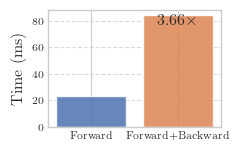

In [79]:
import time
import torch
import os
import json
import matplotlib.pyplot as plt

# --- Setup ---
for param in model.parameters():
    param.requires_grad = False

x = next(iter(test_loader_transformed))[0].to(device)

def timing_cache_path(modelname, transform_name, dataset, architecture):
    base = os.path.join(current_path, "experiment_files", "export", "results", "timing_forward_backward")
    os.makedirs(base, exist_ok=True)
    fname = f"{dataset}_{architecture}_{modelname}_{transform_name}.json"
    return os.path.join(base, fname)

# Usage:
cache_path = timing_cache_path(modelname, transform_name, dataset, architecture)

def run_timing(model, x, n_warmup=20, n_iter=200):
    # Warmup forward
    for _ in range(n_warmup):
        with torch.no_grad():
            _ = model(x)

    # Measure forward
    start = time.time()
    for _ in range(n_iter):
        with torch.no_grad():
            _ = model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    forward_time = time.time() - start

    # Warmup backward
    for _ in range(n_warmup):
        x_tmp = x.detach().clone().requires_grad_(True)
        out = model(x_tmp)
        loss = out.sum()
        loss.backward()
        if device.type == "cuda":
            torch.cuda.synchronize()

    # Measure forward\+backward
    start = time.time()
    for _ in range(n_iter):
        x_tmp = x.detach().clone().requires_grad_(True)
        out = model(x_tmp)
        loss = out.sum()
        loss.backward()
        if device.type == "cuda":
            torch.cuda.synchronize()
    fb_time = time.time() - start

    return forward_time, fb_time

# --- Run or load cache ---
if os.path.exists(cache_path):
    with open(cache_path, "r") as f:
        timing = json.load(f)
    res1, res2 = timing["forward"], timing["forward_backward"]
else:
    if dataset == "tu_berlin":
        model.train()
    res1, res2 = run_timing(model, x)
    if dataset == "tu_berlin":
        model.eval()
    with open(cache_path, "w") as f:
        json.dump({"forward": res1, "forward_backward": res2}, f)

# --- Plot ---
W = plt_setup_latex()
labels = ["Forward", "Forward+Backward"]
means = [res1 / 200 * 1000, res2 / 200 * 1000]

# Compute backward overhead
factor = means[1] / means[0]

plt.figure(figsize=(W/2, W/3))
bars = plt.bar(labels, means, color=["#4C72B0", "#DD8452"], alpha=0.85)
plt.ylabel("Time (ms)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# ---- Write overhead above the second bar ----
plt.text(
    x=1,
    y=means[1] - (0.1 * means[1]),
    s=f"{factor:.2f}×",
    ha='center',
    va='bottom'
)

plt.tight_layout()

# Save as PGF + PDF (no rcParams modified)
save_path = os.path.join(figure_path, "timing_forward_backward_plot")
plt.savefig(save_path + ".pgf")
plt.savefig(save_path + ".pdf")

plt.show()



In [80]:

import time
import os
import torch
import json

from search.objective_generators import _copy_problem_with_init_method

num_batches = 5

batch_warmup = next(iter(test_loader_transformed))[0].to(device)
with torch.no_grad():
    _ = model(batch_warmup)
print("Warm-up done.\n")

benchmark_results = {}

for budget in budgets:
    print(f"\n=== Budget: {budget} ===")
    for algo in all_algos:
        print(f"\n--- Algorithm: {algo} ---")

        # Select problems and names based on algorithm type
        if algo in complex_algos:
            current_problems = problems_complex
            current_problem_names = problem_names_complex
        elif algo in ["shgo_individual", "wcd_lat_ind"]:
            current_problems = problems_individual
            current_problem_names = problem_names_individual
        elif "vector" in algo:
            current_problems = problems_rotvec
            current_problem_names = problem_names_rotvec
        else:
            current_problems = problems
            current_problem_names = problem_names

        # Map algorithm names for construction
        if algo in complex_algos:
            algo_name_for_path = algo_variant_mapping[algo]
        elif algo == "shgo_individual":
            algo_name_for_path = "shgo"
        elif algo == "wcd_lat_ind":
            algo_name_for_path = "wcd_lattice"
        elif "vector" in algo:
            algo_name_for_path = algo.replace("_vector", "")
        else:
            algo_name_for_path = algo

        algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
        os.makedirs(algo_dir, exist_ok=True)
        param_path = os.path.join(algo_dir, "best.yml")
        cache_path = os.path.join(algo_dir, "benchmark_cache.json")
        stored_params = load_params(param_path) if os.path.exists(param_path) else get_default_params(algo_name_for_path, budget)

        # Load cache if exists
        if os.path.exists(cache_path):
            with open(cache_path, "r") as f:
                cache = json.load(f)
        else:
            cache = {}

        search_obj = build_search_algorithm(
            algo_name_for_path,
            stored_params,
            problem=current_problems[0],
            budget=budget,
            model=model,
        )

        for prob, prob_name in zip(current_problems, current_problem_names):
            prob.max_batch_size = dataset_info.batch_size_search

            if algo == "wcd_lat_ind":
                print("Setting lattice basis for WCD Lattice Individual")
                prob = _copy_problem_with_init_method(prob, init_method="permuted_lattice")
            if algo in ["its", "its2", "shgo_individual", "wcd_lat_ind"]:
                prob = ITSWRAPPER._prepare_problem(prob)

            if "vector" in algo:
                prop = replace_rotation_transforms_2vec(prob)

            cache_key = f"{prob_name}"
            if cache_key in cache:
                avg_time = cache[cache_key]["avg_time_per_batch"]
                print(f"[{prob_name}] Avg time (cached): {avg_time:.4f}s")
            else:
                batch_times = []
                data_iter = iter(test_loader_transformed)
                x_first = next(data_iter)
                for _ in range(num_batches):
                    batch = next(data_iter)
                    x_batch = batch[0].to(device)
                    start_time = time.time()
                    search_obj.optimize(prob, x_batch)
                    if device.type == 'cuda':
                        torch.cuda.synchronize()
                    end_time = time.time()
                    batch_times.append(end_time - start_time)
                batch = next(data_iter)
                x_batch = batch[0].to(device)
                start_time = time.time()
                search_obj.optimize(prob, x_batch)
                end_time = time.time()
                batch_times.append(end_time - start_time)
                avg_time = sum(batch_times) / len(batch_times)
                cache[cache_key] = {"avg_time_per_batch": avg_time}
                with open(cache_path, "w") as f:
                    json.dump(cache, f)
                print(f"[{prob_name}] Avg time: {avg_time:.4f}s")

            benchmark_results.setdefault(algo, {})[prob_name] = {
                "avg_time_per_batch": avg_time,
            }

Warm-up done.


=== Budget: 60 ===

--- Algorithm: shgo ---
[logit_energy] Avg time (cached): 0.9599s
[knn_per_class] Avg time (cached): 1.0204s
[learned_energy] Avg time (cached): 0.9239s

--- Algorithm: parallel_sa ---
[logit_energy] Avg time (cached): 1.2206s
[knn_per_class] Avg time (cached): 1.3136s
[learned_energy] Avg time (cached): 1.1676s

--- Algorithm: pso ---
[logit_energy] Avg time (cached): 1.1566s
[knn_per_class] Avg time (cached): 1.3417s
[learned_energy] Avg time (cached): 1.3197s

--- Algorithm: cd ---
[logit_energy] Avg time (cached): 1.2305s
[knn_per_class] Avg time (cached): 1.2697s
[learned_energy] Avg time (cached): 1.1746s

--- Algorithm: wcd ---
[logit_energy] Avg time (cached): 1.0998s
[knn_per_class] Avg time (cached): 1.1117s
[learned_energy] Avg time (cached): 1.0703s

--- Algorithm: its ---
[logit_energy] Avg time (cached): 1.2447s
[knn_per_class] Avg time (cached): 1.2548s
[learned_energy] Avg time (cached): 2.5627s

--- Algorithm: random_search ---
[logi

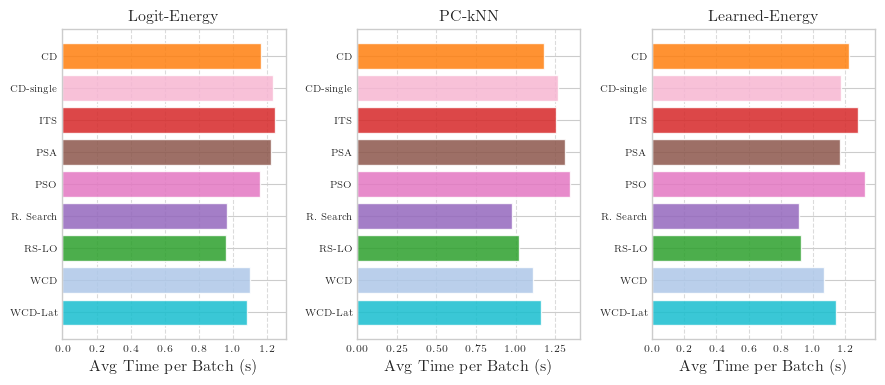

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Collect results into a DataFrame ---
rows = []
for algo, prob_dict in benchmark_results.items():
    for prob_name, metrics in prob_dict.items():
        rows.append({
            "Algorithm": algo,
            "Problem": prob_name,
            "AvgTimePerBatch": metrics["avg_time_per_batch"]
        })
df_time = pd.DataFrame(rows)

# --- Optional: Rename algorithms/problems for nicer plot labels ---
df_time["Algorithm"] = df_time["Algorithm"].replace(ALGO_RENAME)
df_time["Problem"] = df_time["Problem"].replace(PROBLEM_RENAME)

# Adjust for Learned-Energy cases
df_time.loc[
    (df_time["Problem"] == "Learned-Energy") & (df_time["Algorithm"].str.contains("its", case=False)),
    "AvgTimePerBatch"
] /= 2

# --- Plot (Problems on y-axis, horizontal bars) ---
problems = df_time["Problem"].unique()
fig, axes = plt.subplots(1, len(problems), figsize=(len(problems)*3, 4), squeeze=False)
axes = axes[0]

for ax, problem in zip(axes, problems):
    sub = df_time[df_time["Problem"] == problem].sort_values("Algorithm",ascending=False)
    algos = sub["Algorithm"].tolist()
    times = sub["AvgTimePerBatch"].to_numpy()
    y = np.arange(len(algos))
    bar_colors = [algorithm_colors.get(a, (0.5, 0.5, 0.5)) for a in algos]

    ax.barh(y, times, color=bar_colors, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(algos, fontsize=7)
    ax.set_xlabel("Avg Time per Batch (s)")
    ax.set_title(problem)
    ax.grid(axis="x", linestyle="--", alpha=0.7)


plt.tight_layout()
plt.savefig(os.path.join(figure_path, "benchmark_avg_time_per_batch.pdf"))
plt.savefig(os.path.join(figure_path, "benchmark_avg_time_per_batch.pgf"))
plt.show()


In [82]:
stop

NameError: name 'stop' is not defined

In [ ]:
import time
import os
import torch
import torch.nn as nn

# =========================
# CONFIG
# =========================
measure_time = True  # set False to skip the timing benchmark
num_batches = 5      # measured batches (excluding first, plus one extra at end)

# Warm-up the model once to initialize kernels
batch_warmup = next(iter(test_loader_transformed))[0].to(device)
with torch.no_grad():
    _ = model(batch_warmup)
print("Model warm-up done.\n")

# =========================
# BENCHMARK 1: Eval count / cost check
# =========================
print("=== Eval Count / Budget Checking ===")
for budget in budgets:
    print(f"\n--- Budget: {budget} ---")
    for algo in all_algos:
        try:
            if algo == "its" or algo in ["shgo_individual", "wcd_lat_ind"]:
                continue
            if algo in complex_algos:
                continue

            # Load params
            algo_dir = os.path.join(base_results_dir, algo, f"budget_{budget}")
            param_path = os.path.join(algo_dir, "best.yml")
            if os.path.exists(param_path):
                stored_params = load_params(param_path)
            else:
                stored_params = get_default_params(algo, budget)

            # Compute cost
            if algo == "shgo":
                cost = _cost_shgo(
                    stored_params["shgo_initial_samples"],
                    stored_params["shgo_local_runs"],
                    stored_params["shgo_local_steps"],
                    stored_params.get("grad_weight", 2),
                )
            elif algo == "parallel_sa":
                cost = _cost_parallel_sa(
                    stored_params["psa_parallel_runs"],
                    stored_params["psa_max_iterations"],
                )
            elif algo == "evolutionary":
                cost = _cost_es(
                    stored_params["es_population"],
                    stored_params["es_iters"],
                )
            elif algo == "pso":
                cost = _cost_pso(
                    stored_params["pso_swarm_size"],
                    stored_params["pso_steps"],
                )
            elif algo == "cd":
                cost = None
            elif algo == "wcd":
                cost = None
            elif algo in {"pgd", "pgd_restart", "pgd_window"}:
                cost = _cost_pgd(
                    stored_params["pgd_parallel_runs"],
                    stored_params["pgd_max_iterations"],
                    stored_params.get("grad_weight", 2),
                )
            elif algo == "random_search":
                cost = budget
            else:
                cost = None

            # Build a fresh SinglePass energy problem to count model evals
            model_counter = EvalCounterWrapper(model)
            energy_counter_confidence = SinglePassConfidence(model_counter, EnergyConfidence(), index=None)
            problem_energy_counter = TransformationProblem(
                energy_counter_confidence, transform_seq, consolidate_method="consolidate_simple"
            )
            problem_energy_counter.max_batch_size = dataset_info.batch_size_search

            # Run a single batch to count evaluations
            batch = next(iter(test_loader_transformed))
            model_counter.reset()
            search_obj = build_search_algorithm(algo, stored_params, problem=problems[0], budget=budget, model=model_counter)
            search_obj.optimize(problem_energy_counter, x=batch[0].to(device))


            print(f"Algorithm: {algo}")
            print(f"  Computed cost: {cost}")
            print(f"  Budget: {budget}")
            print(f"  Eval count per sample: {model_counter.eval_count / len(batch[0]):.2f}")
        except Exception as e:
            print(f"Error processing algorithm {algo} at budget {budget}: {e}")




In [ ]:
print("\n=== Benchmark Summary ===")
for algo, probs in benchmark_results.items():
    print(f"\nAlgorithm: {algo}")
    for prob_name, metrics in probs.items():
        print(f"  {prob_name}: Time {metrics['avg_time_per_batch']:.4f}s")

In [ ]:
stop

In [ ]:
import json
import os
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# === Locate base path ===
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

# === Import to get transform names dynamically ===
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info

# === Configuration ===
datasets = ["bigger_mnist", "coil100", "bigger_emnist", "modelnet10"]
budget = 60
base_path = Path(current_path) / "experiment_files" / "search_results"

# === Architecture mapping ===
default_architecture_mapping = {
    "mnist": "resnet_small",
    "bigger_mnist": "resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist": "bigger_extended_resnet_small",
    "coil100": "coil_resnet_small",
    "tu_berlin": "bi_lstm",
    "modelnet10": "pointnetplus",
}

problem_names = ["logit_energy", "knn_per_class", "learned_energy"]

# === Collect all data ===
# Structure: data_dict[algo][problem][dataset] = list of (accuracy, se)
data_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for dataset in datasets:
    dataset_info = get_dataset_info(dataset)
    transform_name = dataset_info.transform_seq_name
    architecture = default_architecture_mapping[dataset]

    dataset_path = base_path / dataset / transform_name / architecture
    print(f"Checking path for {dataset}: {dataset_path}")

    if not dataset_path.exists():
        print(f"Warning: Path does not exist for {dataset}: {dataset_path}")
        continue

    for algo_dir in dataset_path.iterdir():
        if not algo_dir.is_dir():
            continue

        algo_name = algo_dir.name
        budget_dir = algo_dir / f"budget_{budget}"

        if not budget_dir.exists():
            continue

        for problem_name in problem_names:
            eval_file = budget_dir / f"eval_{problem_name}.json"
            if not eval_file.exists():
                continue

            try:
                with open(eval_file, 'r') as f:
                    metrics = json.load(f)

                accuracy = metrics.get("accuracy_mean")
                accuracy_se = metrics.get("accuracy_se")

                if accuracy is not None:
                    data_dict[algo_name][problem_name][dataset].append(
                        {"mean": accuracy, "se": accuracy_se}
                    )

            except Exception as e:
                print(f"Error reading {eval_file}: {e}")

In [ ]:
# === Identify algorithms that appear in ALL datasets ===
all_algorithms = set(data_dict.keys())
algorithms_in_all = set()

for algo in all_algorithms:
    datasets_with_algo = set()
    for problem in problem_names:
        datasets_with_algo.update(data_dict[algo][problem].keys())

    if datasets_with_algo == set(datasets):
        algorithms_in_all.add(algo)

print(f"\nAlgorithms appearing in all datasets: {sorted(algorithms_in_all)}")

# === Compute per-dataset statistics ===
results = []

for algo in sorted(algorithms_in_all):
    for problem in problem_names:
        for dataset in datasets:
            entries = data_dict[algo][problem][dataset]
            if not entries:
                continue

            # Extract values
            accuracies = [e["mean"] for e in entries if e["mean"] is not None]
            ses = [e["se"] for e in entries if e["se"] is not None]

            if accuracies:
                mean_acc = np.mean(accuracies)
                std_acc = np.std(accuracies, ddof=1) if len(accuracies) > 1 else 0.0
                se_acc = np.mean(ses) if ses else std_acc / np.sqrt(len(accuracies))

                results.append({
                    "Dataset": dataset,
                    "Algorithm": algo,
                    "Problem": problem,
                    "Mean_Accuracy": mean_acc,
                    "Std_Accuracy": std_acc,
                    "SE_Accuracy": se_acc,
                    "N_Samples": len(accuracies),
                })

# === Create and display DataFrame ===
df_results = pd.DataFrame(results)

if not df_results.empty:
    print("\n=== Results Per Dataset ===\n")
    for dataset in datasets:
        print(f"\n=== Dataset: {dataset} ===")
        for problem in problem_names:
            subset = df_results[
                (df_results["Dataset"] == dataset) &
                (df_results["Problem"] == problem)
            ].sort_values("Mean_Accuracy", ascending=False)
            if not subset.empty:
                print(f"\n--- Problem: {problem} ---")
                print(subset.to_string(index=False))

    # Save to CSV
    output_file = base_path / "aggregated_results_per_dataset.csv"
    df_results.to_csv(output_file, index=False)
    print(f"\nResults saved to: {output_file}")
else:
    print("\nNo results found. Check if the paths are correct and data exists.")